# Online Retail Growth, Retention, and CLV Project 

In [1]:
#! pip install pandas numpy matplotlib seaborn scikit-learn xgboost lifelines lifetimes mlxtend networkx

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, mean_absolute_error,
    mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier, XGBRegressor

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 1. Data Reading and Preprocessing 
- It can construct order-level, customer-level, and customer-month-level analysis tables


In [3]:
# ========== 2.load data ==========
file_path = "df_clean.csv"  # e.g. "./data/online_retail.csv"

df = pd.read_csv(file_path)

# Basic field processing
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["OrderDate"] = df["InvoiceDate"].dt.date
df["Revenue"] = df["Revenue"].astype(float)

# Ensure that the CustomerID is a string to avoid issues related to numerical precision or null values.
df = df.dropna(subset=["CustomerID", "InvoiceNo", "StockCode", "InvoiceDate", "Revenue"])
df["CustomerID"] = df["CustomerID"].astype(str)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

print(df.shape)
display(df.head())
print(df.dtypes)


(397884, 17)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Date,YearMonth,Week,DayOfWeek,IsWeekend,Hour,Revenue,OrderDate
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,20.34,2010-12-01


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
IsReturn                 bool
Date           datetime64[ns]
YearMonth              object
Week                    int64
DayOfWeek               int64
IsWeekend               int64
Hour                    int64
Revenue               float64
OrderDate              object
dtype: object


In [4]:

print("time scale:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())
print("The number of customers:", df["CustomerID"].nunique())
print("The number of  orders:", df["InvoiceNo"].nunique())
print("The number of SKU:", df["StockCode"].nunique())
print("The number of countrys:", df["Country"].nunique())


order_level = (
    df.groupby("InvoiceNo")
      .agg(
          CustomerID=("CustomerID", "first"),
          InvoiceDate=("InvoiceDate", "min"),
          Country=("Country", "first"),
          order_revenue=("Revenue", "sum"),
          items=("Quantity", "sum"),
          unique_skus=("StockCode", "nunique"),
          lines=("StockCode", "count")
      )
      .reset_index()
)

order_level["YearMonth"] = order_level["InvoiceDate"].dt.to_period("M").astype(str)
order_level["Date"] = order_level["InvoiceDate"].dt.date

display(order_level.head())


time scale: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
The number of customers: 4338
The number of  orders: 18532
The number of SKU: 3665
The number of countrys: 37


,InvoiceNo,CustomerID,InvoiceDate,Country,order_revenue,items,unique_skus,lines,YearMonth,Date
0,536365,17850,2010-12-01 08:26:00,United Kingdom,139.12,40,7,7,2010-12,2010-12-01
1,536366,17850,2010-12-01 08:28:00,United Kingdom,22.20,12,2,2,2010-12,2010-12-01
2,536367,13047,2010-12-01 08:34:00,United Kingdom,278.73,83,12,12,2010-12,2010-12-01
3,536368,13047,2010-12-01 08:34:00,United Kingdom,70.05,15,4,4,2010-12,2010-12-01
4,536369,13047,2010-12-01 08:35:00,United Kingdom,17.85,3,1,1,2010-12,2010-12-01


## 2. Growth Diagnosis: Whether the business is growing and what drives the growth 
Analysis logic: 
1. Review the core business indicators on a monthly basis.
2. Use the formula: `Revenue = Customers × Frequency × AOV`.


In [5]:
# ========== 4. Monthly growth indicator ==========
monthly = (
    order_level.groupby("YearMonth")
    .agg(
        Revenue=("order_revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique"),
        AvgItemsPerOrder=("items", "mean"),
        AvgUniqueSkuPerOrder=("unique_skus", "mean"),
        MultiSkuOrderShare=("unique_skus", lambda x: (x > 1).mean())
    )
    .reset_index()
)

monthly["AOV"] = monthly["Revenue"] / monthly["Orders"]
monthly["Frequency"] = monthly["Orders"] / monthly["Customers"]
monthly["ARPU"] = monthly["Revenue"] / monthly["Customers"]

display(monthly)


,YearMonth,Revenue,Customers,Orders,AvgItemsPerOrder,AvgUniqueSkuPerOrder,MultiSkuOrderShare,AOV,Frequency,ARPU
0,2010-12,572713.890,885,1400,223.046429,18.075000,0.902857,409.081350,1.581921,647.134339
1,2011-01,569445.040,741,987,353.696049,21.045593,0.929078,576.945329,1.331984,768.481835
2,2011-02,447137.350,758,997,266.421264,19.555667,0.930792,448.482798,1.315303,589.890963
3,2011-03,595500.760,974,1321,263.817562,20.146858,0.935655,450.795428,1.356263,611.397084
4,2011-04,469200.361,856,1149,254.327241,19.385553,0.918190,408.355406,1.342290,548.131263
5,2011-05,678594.560,1056,1555,240.257878,17.928617,0.912540,436.395215,1.472538,642.608485
6,2011-06,661213.690,991,1393,261.090452,19.187365,0.915291,474.668837,1.405651,667.218658
7,2011-07,600091.011,949,1331,277.550714,19.791886,0.931630,450.857258,1.402529,632.340370
8,2011-08,645343.900,935,1280,311.032031,20.746875,0.915625,504.174922,1.368984,690.207380
9,2011-09,952838.382,1266,1755,310.482621,22.403989,0.937322,542.927853,1.386256,752.636953


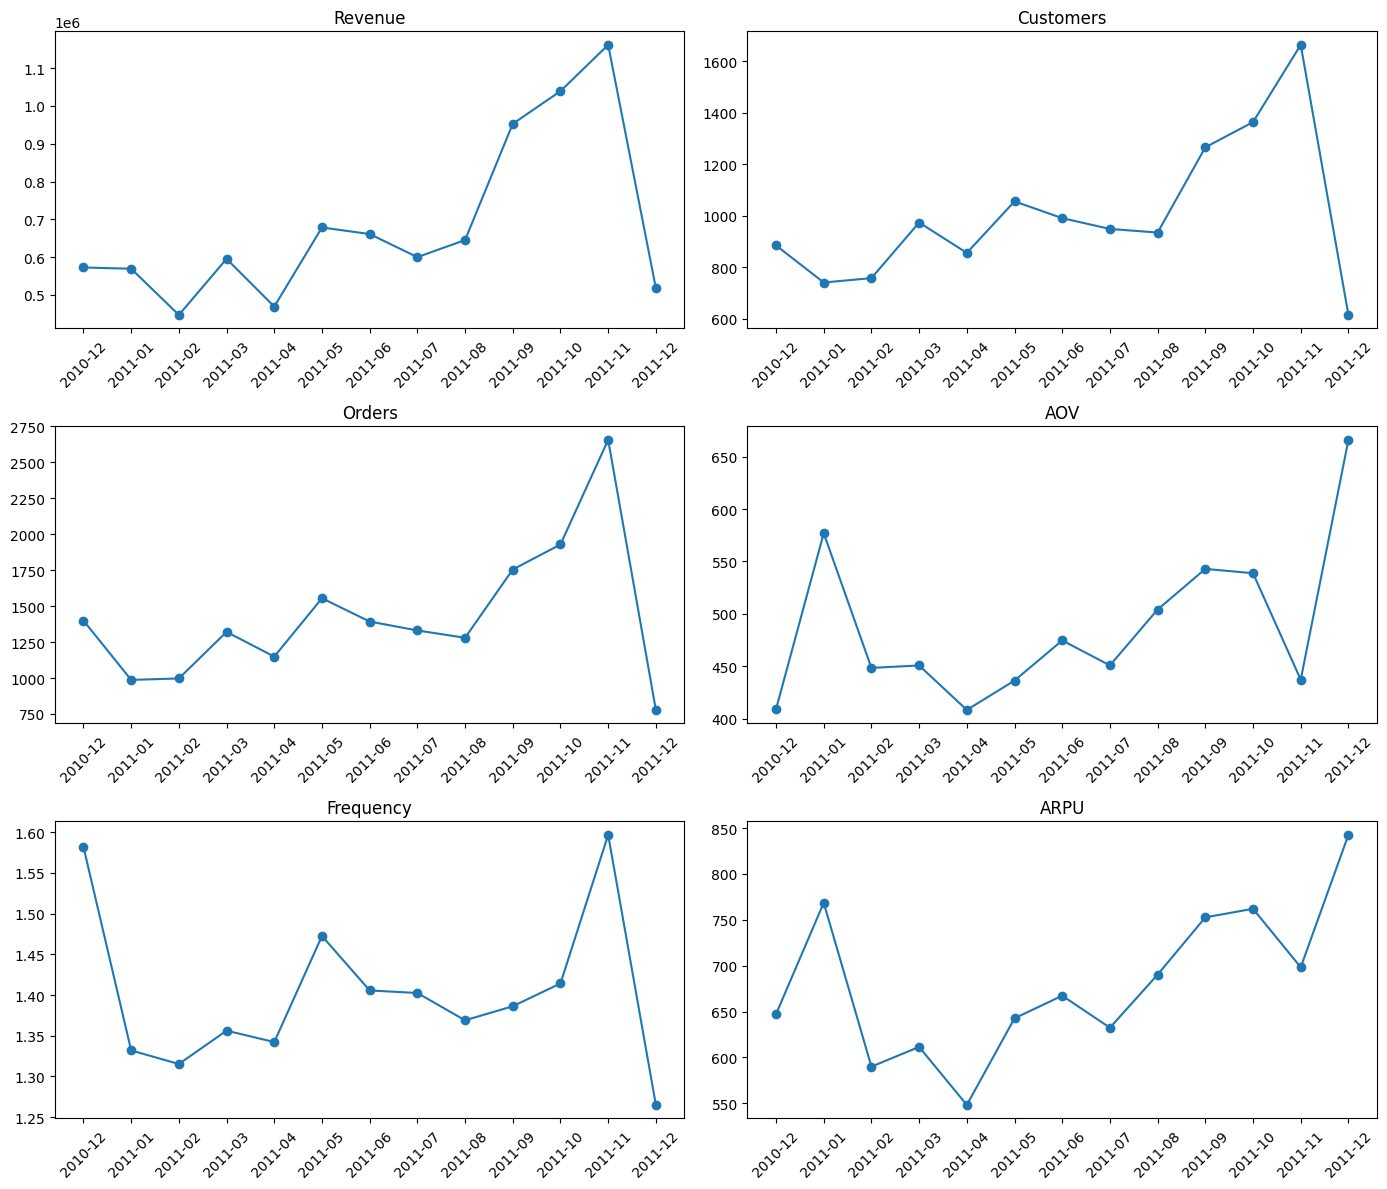

In [6]:
# ========== 5. Monthly trend visualization ==========
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

plot_cols = ["Revenue", "Customers", "Orders", "AOV", "Frequency", "ARPU"]

for ax, col in zip(axes, plot_cols):
    ax.plot(monthly["YearMonth"], monthly[col], marker="o")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [7]:
# ========== 6. Revenue = Customers × Frequency × AOV Growth decomposition ==========
growth = monthly.copy()
for col in ["Revenue", "Customers", "Frequency", "AOV"]:
    growth[f"{col}_pct_change"] = growth[col].pct_change()

for col in ["Revenue", "Customers", "Frequency", "AOV"]:
    growth[f"log_{col}"] = np.log(growth[col].replace(0, np.nan))
    growth[f"dlog_{col}"] = growth[f"log_{col}"].diff()

growth["dlog_Revenue_approx"] = growth["dlog_Customers"] + growth["dlog_Frequency"] + growth["dlog_AOV"]

display(growth[[
    "YearMonth", "Revenue", "Customers", "Frequency", "AOV",
    "dlog_Revenue", "dlog_Customers", "dlog_Frequency", "dlog_AOV", "dlog_Revenue_approx"
]])


,YearMonth,Revenue,Customers,Frequency,AOV,dlog_Revenue,dlog_Customers,dlog_Frequency,dlog_AOV,dlog_Revenue_approx
0,2010-12,572713.890,885,1.581921,409.081350,NaN,NaN,NaN,NaN,NaN
1,2011-01,569445.040,741,1.331984,576.945329,-0.005724,-0.177587,-0.171970,0.343833,-0.005724
2,2011-02,447137.350,758,1.315303,448.482798,-0.241796,0.022683,-0.012602,-0.251877,-0.241796
3,2011-03,595500.760,974,1.356263,450.795428,0.286537,0.250728,0.030666,0.005143,0.286537
4,2011-04,469200.361,856,1.342290,408.355406,-0.238373,-0.129141,-0.010356,-0.098876,-0.238373
5,2011-05,678594.560,1056,1.472538,436.395215,0.368994,0.209973,0.092610,0.066410,0.368994
6,2011-06,661213.690,991,1.405651,474.668837,-0.025947,-0.063529,-0.046487,0.084069,-0.025947
7,2011-07,600091.011,949,1.402529,450.857258,-0.096996,-0.043306,-0.002223,-0.051467,-0.096996
8,2011-08,645343.900,935,1.368984,504.174922,0.072702,-0.014862,-0.024208,0.111772,0.072702
9,2011-09,952838.382,1266,1.386256,542.927853,0.389662,0.303071,0.012538,0.074053,0.389662


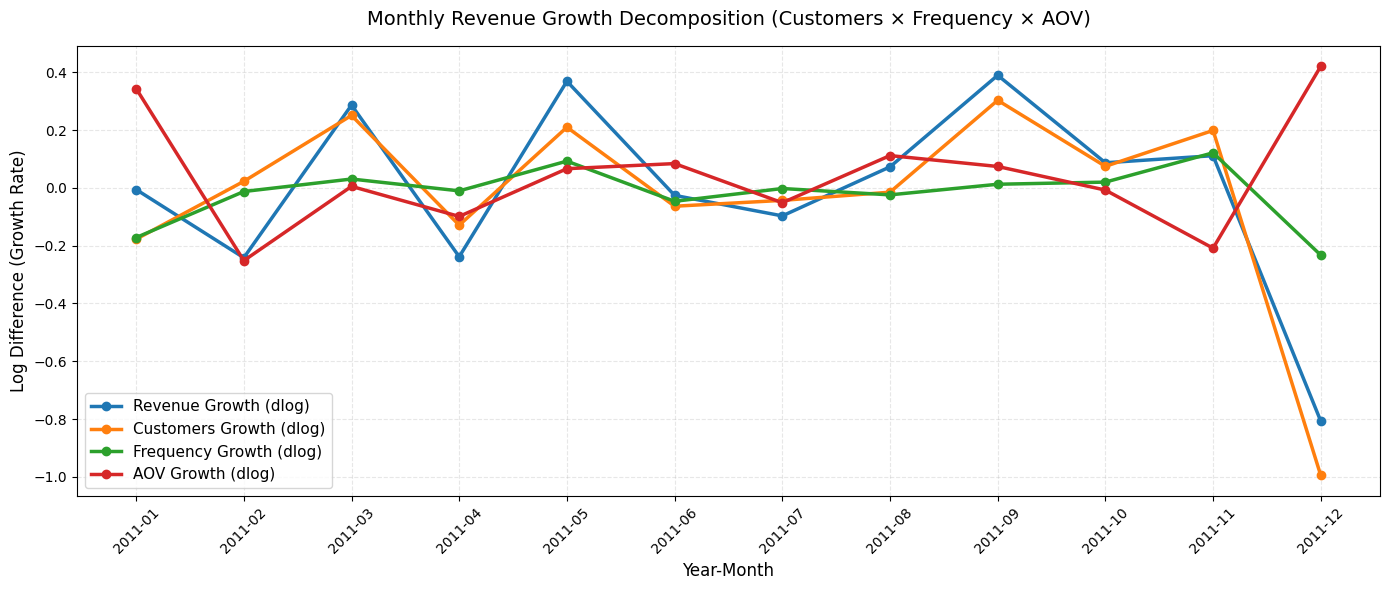

In [8]:
plt.figure(figsize=(14, 6))  

# Draw four trend lines.
plt.plot(growth["YearMonth"], growth["dlog_Revenue"], label="Revenue Growth (dlog)", linewidth=2.5, marker='o')
plt.plot(growth["YearMonth"], growth["dlog_Customers"], label="Customers Growth (dlog)", linewidth=2.5, marker='o')
plt.plot(growth["YearMonth"], growth["dlog_Frequency"], label="Frequency Growth (dlog)", linewidth=2.5, marker='o')
plt.plot(growth["YearMonth"], growth["dlog_AOV"], label="AOV Growth (dlog)", linewidth=2.5, marker='o')


plt.title("Monthly Revenue Growth Decomposition (Customers × Frequency × AOV)", fontsize=14, pad=15)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Log Difference (Growth Rate)", fontsize=12)


plt.xticks(rotation=45)


plt.legend(fontsize=11)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()

plt.show()

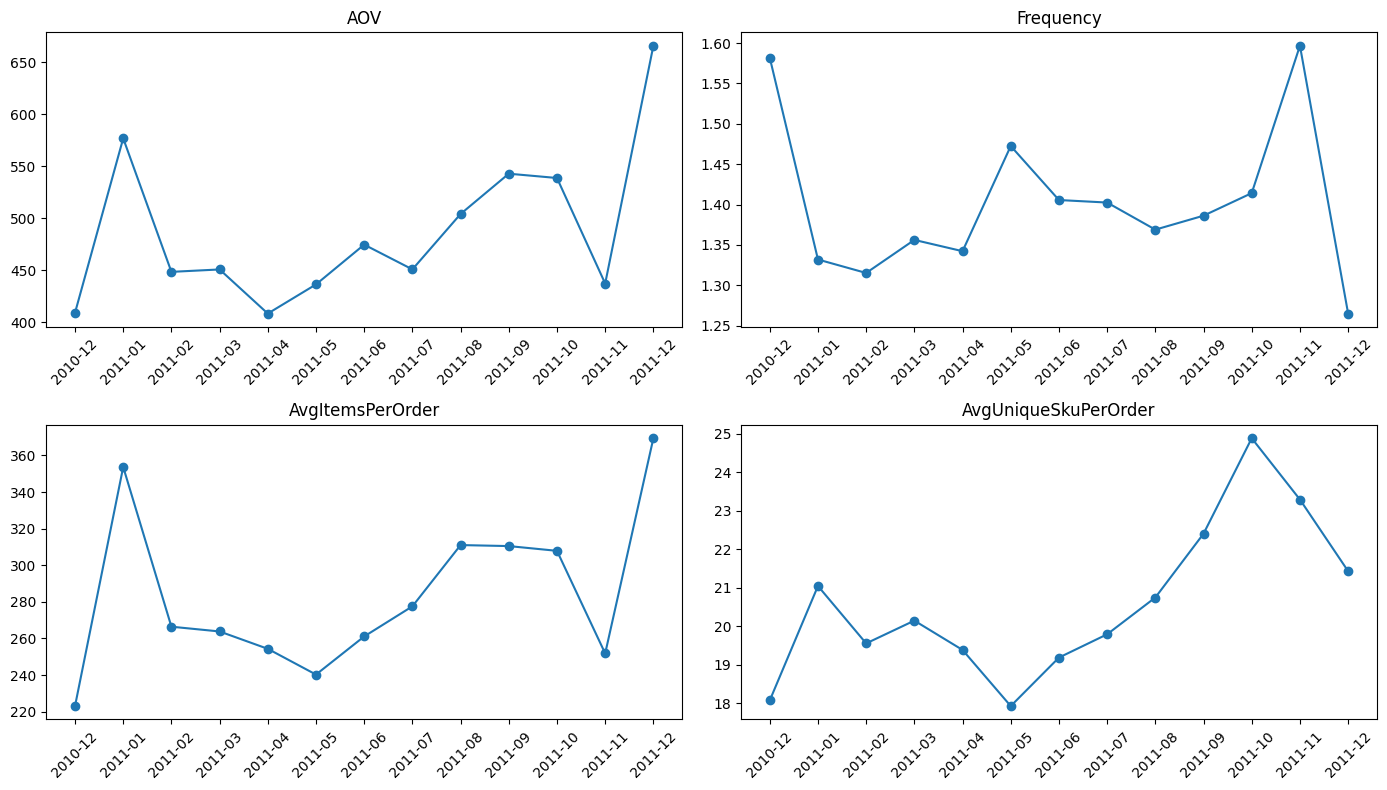

In [9]:
# ========== 7. AOV / Frequency explanation ==========
# Explain the changes in AOV and Frequency through the number of products at the order level and the proportion of multiple SKUs
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ["AOV", "Frequency", "AvgItemsPerOrder", "AvgUniqueSkuPerOrder"]

for ax, col in zip(axes.flatten(), cols):
    ax.plot(monthly["YearMonth"], monthly[col], marker="o")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3. customer-month panel

Subsequent life cycle, survival analysis, retention prediction, and customer segmentation all rely on this core table.


In [10]:
# ========== 8. Build customer-month panel with distribution-calibrated timing thresholds ==========
from pandas.tseries.offsets import MonthEnd

# Customer-month aggregation
customer_month = (
    order_level.groupby(["CustomerID", "YearMonth"])
    .agg(
        month_orders=("InvoiceNo", "nunique"),
        month_revenue=("order_revenue", "sum"),
        month_items=("items", "sum"),
        month_unique_skus=("unique_skus", "sum"),
        avg_order_value=("order_revenue", "mean"),
        month_last_purchase_date=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_month["month"] = pd.PeriodIndex(customer_month["YearMonth"], freq="M").to_timestamp()
customer_month["month_end"] = customer_month["month"] + MonthEnd(0)

# ------------------------------------------
# Calibrate lifecycle boundaries from the empirical interpurchase-gap distribution
# ------------------------------------------
purchase_sequence = (
    order_level.sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
    [["CustomerID", "InvoiceDate", "InvoiceNo"]]
    .drop_duplicates(subset=["CustomerID", "InvoiceNo"])
    .copy()
)

purchase_sequence["prev_purchase_date"] = purchase_sequence.groupby("CustomerID")["InvoiceDate"].shift(1)
purchase_sequence["gap_days"] = (
    purchase_sequence["InvoiceDate"] - purchase_sequence["prev_purchase_date"]
).dt.days

gap_distribution = purchase_sequence["gap_days"].dropna()

gap_p50_days = int(np.ceil(gap_distribution.quantile(0.50)))
gap_p75_days = int(np.ceil(gap_distribution.quantile(0.75)))
gap_p90_days = int(np.ceil(gap_distribution.quantile(0.90)))

print("Empirical interpurchase-gap thresholds (days)")
print(f"P50: {gap_p50_days}")
print(f"P75: {gap_p75_days}")
print(f"P90: {gap_p90_days}")

# ------------------------------------------
# Build the full customer x month panel
# ------------------------------------------
all_customers = customer_month["CustomerID"].drop_duplicates().sort_values().tolist()
all_months = pd.period_range(
    customer_month["month"].min(),
    customer_month["month"].max(),
    freq="M"
).to_timestamp()

panel = pd.MultiIndex.from_product(
    [all_customers, all_months],
    names=["CustomerID", "month"]
).to_frame(index=False)

panel["YearMonth"] = panel["month"].dt.to_period("M").astype(str)
panel["month_end"] = panel["month"] + MonthEnd(0)

panel = panel.merge(
    customer_month.drop(columns=["YearMonth", "month_end"]),
    on=["CustomerID", "month"],
    how="left"
)

fill_cols = [
    "month_orders",
    "month_revenue",
    "month_items",
    "month_unique_skus",
    "avg_order_value"
]
panel[fill_cols] = panel[fill_cols].fillna(0)

panel["is_active"] = (panel["month_orders"] > 0).astype(int)

# Customer first purchase date / month
first_purchase = (
    order_level.groupby("CustomerID")
    .agg(
        first_purchase_date=("InvoiceDate", "min")
    )
    .reset_index()
)

first_purchase["first_purchase_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

panel = panel.merge(first_purchase, on="CustomerID", how="left")

panel["customer_age_months"] = (
    (panel["month"].dt.year - panel["first_purchase_month"].dt.year) * 12 +
    (panel["month"].dt.month - panel["first_purchase_month"].dt.month)
)

# Keep only months on/after first purchase month
panel = panel[panel["customer_age_months"] >= 0].copy()
panel = panel.sort_values(["CustomerID", "month"]).reset_index(drop=True)

display(panel.head(20))

Empirical interpurchase-gap thresholds (days)
P50: 21
P75: 51
P90: 103


,CustomerID,month,YearMonth,month_end,month_orders,month_revenue,month_items,month_unique_skus,avg_order_value,month_last_purchase_date,is_active,first_purchase_date,first_purchase_month,customer_age_months
0,12346,2011-01-01,2011-01,2011-01-31,1.0,77183.60,74215.0,1.0,77183.60,2011-01-18 10:01:00,1,2011-01-18 10:01:00,2011-01-01,0
1,12346,2011-02-01,2011-02,2011-02-28,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,1
2,12346,2011-03-01,2011-03,2011-03-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,2
3,12346,2011-04-01,2011-04,2011-04-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,3
4,12346,2011-05-01,2011-05,2011-05-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,4
5,12346,2011-06-01,2011-06,2011-06-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,5
6,12346,2011-07-01,2011-07,2011-07-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,6
7,12346,2011-08-01,2011-08,2011-08-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,7
8,12346,2011-09-01,2011-09,2011-09-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,8
9,12346,2011-10-01,2011-10,2011-10-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,9


In [11]:
# Sort by "month_orders" in descending order (from largest to smallest)
customer_month_sorted = customer_month.sort_values(by="month_orders", ascending=False)

display(customer_month_sorted.head(20))

,CustomerID,YearMonth,month_orders,month_revenue,month_items,month_unique_skus,avg_order_value,month_last_purchase_date,month,month_end
1036,12748,2011-11,45,10639.23,8622,1529,236.427333,2011-11-29 18:14:00,2011-11-01,2011-11-30
1025,12748,2010-12,35,4228.13,2841,636,120.803714,2010-12-23 15:32:00,2010-12-01,2010-12-31
5840,14911,2011-11,34,22720.73,12462,917,668.256765,2011-11-30 15:08:00,2011-11-01,2011-11-30
12156,17850,2010-12,34,5391.21,1733,297,158.565000,2010-12-02 15:27:00,2010-12-01,2010-12-31
5838,14911,2011-09,28,21271.97,11182,891,759.713214,2011-09-30 13:46:00,2011-09-01,2011-09-30
1030,12748,2011-05,24,2234.50,1326,261,93.104167,2011-05-31 12:50:00,2011-05-01,2011-05-31
5839,14911,2011-10,24,18416.39,13235,791,767.349583,2011-10-31 14:22:00,2011-10-01,2011-10-31
5835,14911,2011-06,17,10078.20,5766,369,592.835294,2011-06-30 15:46:00,2011-06-01,2011-06-30
12139,17841,2011-11,16,7143.58,4129,1293,446.473750,2011-11-29 17:52:00,2011-11-01,2011-11-30
1035,12748,2011-10,16,2292.84,3055,207,143.302500,2011-10-26 13:56:00,2011-10-01,2011-10-31


## 4.Determine the type of users contribute to the increase in revenue

In [12]:
# ========== 9. Lifecycle features with distribution-calibrated state boundaries ==========
g = panel.groupby("CustomerID")

panel["prev_active"] = g["is_active"].shift(1).fillna(0)
panel["cum_active_months_before"] = g["is_active"].cumsum() - panel["is_active"]

# Forward-fill the most recent purchase date at the monthly level
panel["last_purchase_date"] = panel["month_last_purchase_date"]
panel["last_purchase_date"] = g["last_purchase_date"].ffill()

# Recency in days relative to the end of each month
panel["days_since_last_purchase"] = (
    panel["month_end"] - panel["last_purchase_date"]
).dt.days

panel["days_since_last_purchase"] = panel["days_since_last_purchase"].fillna(0).clip(lower=0)

# Rolling behavior features
for win in [3, 6]:
    panel[f"orders_last_{win}m"] = (
        g["month_orders"]
        .transform(lambda s: s.rolling(win, min_periods=1).sum().shift(1))
        .fillna(0)
    )
    panel[f"revenue_last_{win}m"] = (
        g["month_revenue"]
        .transform(lambda s: s.rolling(win, min_periods=1).sum().shift(1))
        .fillna(0)
    )
    panel[f"active_months_last_{win}m"] = (
        g["is_active"]
        .transform(lambda s: s.rolling(win, min_periods=1).sum().shift(1))
        .fillna(0)
    )

# Lifecycle state definition calibrated by the empirical purchase-gap distribution
def lifecycle_state(row):
    if row["is_active"] == 1 and row["month"] == row["first_purchase_month"]:
        return "new"
    elif row["is_active"] == 1 and row["prev_active"] == 1:
        return "retained"
    elif row["is_active"] == 1 and row["prev_active"] == 0 and row["cum_active_months_before"] > 0:
        return "reactivated"
    elif row["is_active"] == 0 and row["days_since_last_purchase"] <= gap_p90_days:
        return "at_risk"
    else:
        return "inactive"

panel["lifecycle_state"] = panel.apply(lifecycle_state, axis=1)

state_order = [
    "new",
    "retained",
    "reactivated",
    "at_risk",
    "inactive"
]

panel["lifecycle_state"] = pd.Categorical(
    panel["lifecycle_state"],
    categories=state_order,
    ordered=True
)

display(panel.head(20))

,CustomerID,month,YearMonth,month_end,month_orders,month_revenue,month_items,month_unique_skus,avg_order_value,month_last_purchase_date,is_active,first_purchase_date,first_purchase_month,customer_age_months,prev_active,cum_active_months_before,last_purchase_date,days_since_last_purchase,orders_last_3m,revenue_last_3m,active_months_last_3m,orders_last_6m,revenue_last_6m,active_months_last_6m,lifecycle_state
0,12346,2011-01-01,2011-01,2011-01-31,1.0,77183.60,74215.0,1.0,77183.60,2011-01-18 10:01:00,1,2011-01-18 10:01:00,2011-01-01,0,0.0,0,2011-01-18 10:01:00,12,0.0,0.00,0.0,0.0,0.00,0.0,new
1,12346,2011-02-01,2011-02,2011-02-28,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,1,1.0,1,2011-01-18 10:01:00,40,1.0,77183.60,1.0,1.0,77183.60,1.0,at_risk
2,12346,2011-03-01,2011-03,2011-03-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,2,0.0,1,2011-01-18 10:01:00,71,1.0,77183.60,1.0,1.0,77183.60,1.0,at_risk
3,12346,2011-04-01,2011-04,2011-04-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,3,0.0,1,2011-01-18 10:01:00,101,1.0,77183.60,1.0,1.0,77183.60,1.0,at_risk
4,12346,2011-05-01,2011-05,2011-05-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,4,0.0,1,2011-01-18 10:01:00,132,0.0,0.00,0.0,1.0,77183.60,1.0,inactive
5,12346,2011-06-01,2011-06,2011-06-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,5,0.0,1,2011-01-18 10:01:00,162,0.0,0.00,0.0,1.0,77183.60,1.0,inactive
6,12346,2011-07-01,2011-07,2011-07-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,6,0.0,1,2011-01-18 10:01:00,193,0.0,0.00,0.0,1.0,77183.60,1.0,inactive
7,12346,2011-08-01,2011-08,2011-08-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,7,0.0,1,2011-01-18 10:01:00,224,0.0,0.00,0.0,0.0,0.00,0.0,inactive
8,12346,2011-09-01,2011-09,2011-09-30,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,8,0.0,1,2011-01-18 10:01:00,254,0.0,0.00,0.0,0.0,0.00,0.0,inactive
9,12346,2011-10-01,2011-10,2011-10-31,0.0,0.00,0.0,0.0,0.00,NaT,0,2011-01-18 10:01:00,2011-01-01,9,0.0,1,2011-01-18 10:01:00,285,0.0,0.00,0.0,0.0,0.00,0.0,inactive


lifecycle_state,new,retained,reactivated,total_active_customers,new_share,retained_share,reactivated_share,new_mom_change,retained_mom_change,reactivated_mom_change,total_active_customers_mom_change
YearMonth,,,,,,,,,,,
2010-12,885,0,0,885,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2011-01,417,324,0,741,0.562753,0.437247,0.000000,-468.0,324.0,0.0,-144.0
2011-02,380,262,116,758,0.501319,0.345646,0.153034,-37.0,-62.0,116.0,17.0
2011-03,452,290,232,974,0.464066,0.297741,0.238193,72.0,28.0,116.0,216.0
2011-04,300,304,252,856,0.350467,0.355140,0.294393,-152.0,14.0,20.0,-118.0
2011-05,284,368,404,1056,0.268939,0.348485,0.382576,-16.0,64.0,152.0,200.0
2011-06,242,410,339,991,0.244198,0.413724,0.342079,-42.0,42.0,-65.0,-65.0
2011-07,188,365,396,949,0.198103,0.384615,0.417281,-54.0,-45.0,57.0,-42.0
2011-08,169,388,378,935,0.180749,0.414973,0.404278,-19.0,23.0,-18.0,-14.0


lifecycle_state,new,retained,reactivated,total_revenue,new_share,retained_share,reactivated_share,new_mom_change,retained_mom_change,reactivated_mom_change,total_revenue_mom_change
YearMonth,,,,,,,,,,,
2010-12,572713.890,0.00,0.000,572713.890,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2011-01,293207.350,276237.69,0.000,569445.040,0.514900,0.485100,0.000000,-279506.540,276237.69,0.000,-3268.850
2011-02,158142.070,215663.52,73331.760,447137.350,0.353677,0.482321,0.164003,-135065.280,-60574.17,73331.760,-122307.690
2011-03,200069.960,275797.81,119632.990,595500.760,0.335969,0.463136,0.200895,41927.890,60134.29,46301.230,148363.410
2011-04,122011.491,215482.02,131706.850,469200.361,0.260041,0.459254,0.280705,-78058.469,-60315.79,12073.860,-126300.399
2011-05,124103.780,363280.99,191209.790,678594.560,0.182884,0.535343,0.281773,2092.289,147798.97,59502.940,209394.199
2011-06,135742.950,378689.76,146780.980,661213.690,0.205294,0.572719,0.221987,11639.170,15408.77,-44428.810,-17380.870
2011-07,74008.751,322100.96,203981.300,600091.011,0.123329,0.536754,0.339917,-61734.199,-56588.80,57200.320,-61122.679
2011-08,79756.100,353658.97,211928.830,645343.900,0.123587,0.548016,0.328397,5747.349,31558.01,7947.530,45252.889


lifecycle_state,new_customers,retained_customers,reactivated_customers,total_active_customers,new_revenue,retained_revenue,reactivated_revenue,total_revenue
YearMonth,,,,,,,,
2010-12,885,0,0,885,572713.890,0.00,0.000,572713.890
2011-01,417,324,0,741,293207.350,276237.69,0.000,569445.040
2011-02,380,262,116,758,158142.070,215663.52,73331.760,447137.350
2011-03,452,290,232,974,200069.960,275797.81,119632.990,595500.760
2011-04,300,304,252,856,122011.491,215482.02,131706.850,469200.361
2011-05,284,368,404,1056,124103.780,363280.99,191209.790,678594.560
2011-06,242,410,339,991,135742.950,378689.76,146780.980,661213.690
2011-07,188,365,396,949,74008.751,322100.96,203981.300,600091.011
2011-08,169,388,378,935,79756.100,353658.97,211928.830,645343.900


<Figure size 1200x500 with 0 Axes>

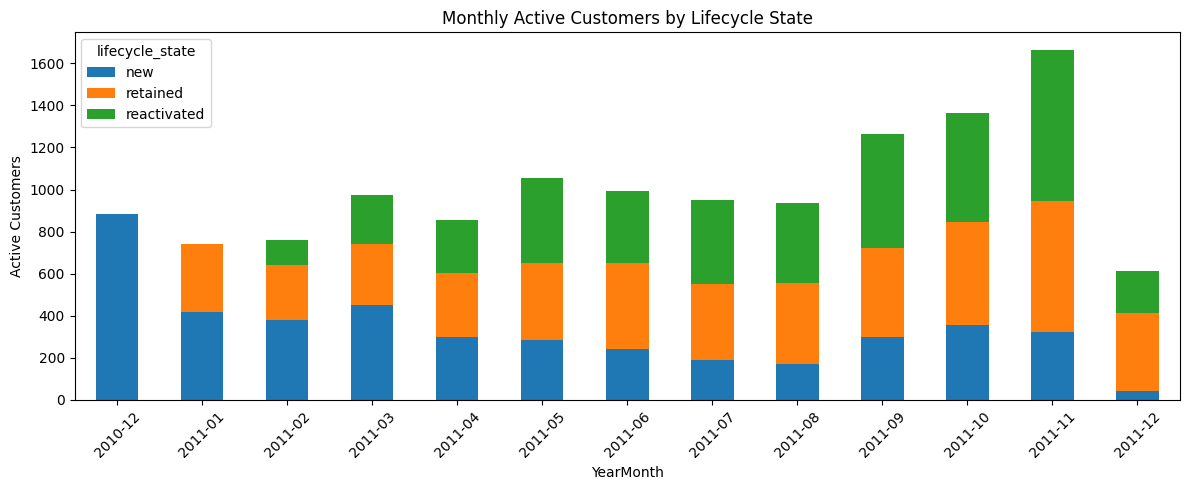

<Figure size 1200x500 with 0 Axes>

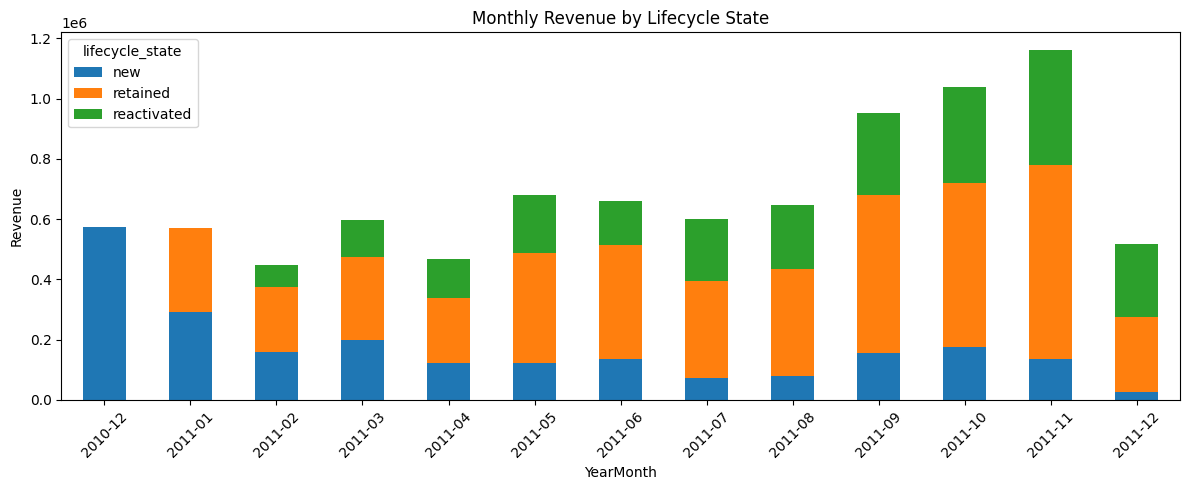

<Figure size 1200x500 with 0 Axes>

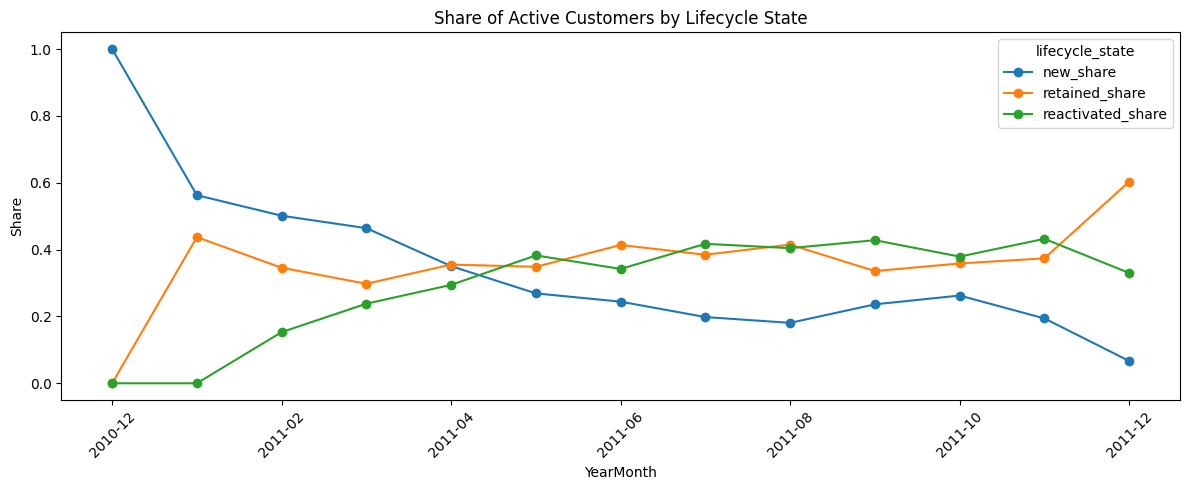

<Figure size 1200x500 with 0 Axes>

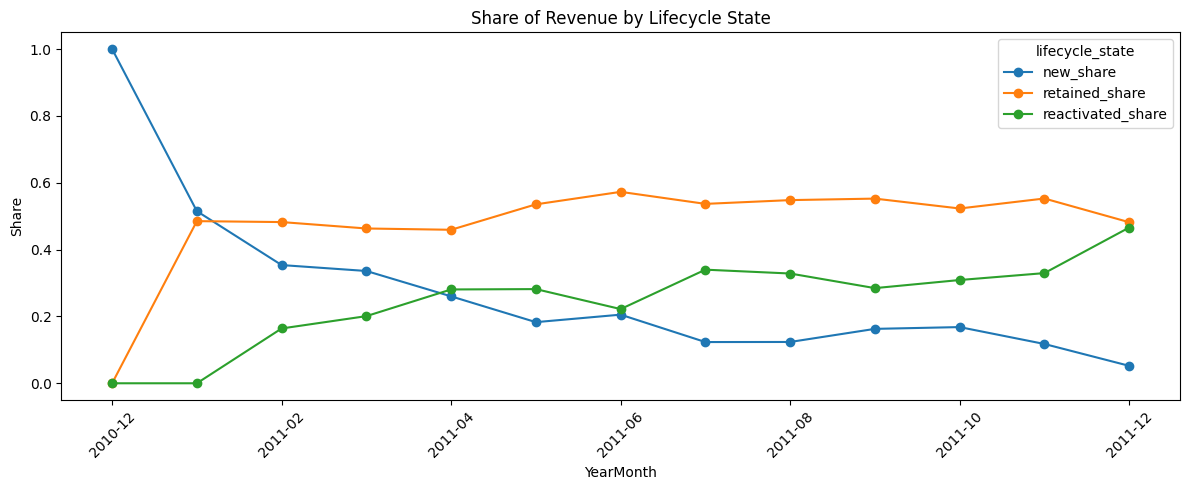

In [13]:
# ========== 9.5 Decompose customer growth by lifecycle state ==========
import matplotlib.pyplot as plt

# Keep only active customer states that can directly contribute to current-month revenue
growth_states = ["new", "retained", "reactivated"]

growth_driver = (
    panel[
        (panel["is_active"] == 1) &
        (panel["lifecycle_state"].isin(growth_states))
    ]
    .groupby(["YearMonth", "lifecycle_state"])
    .agg(
        active_customers=("CustomerID", "nunique"),
        revenue=("month_revenue", "sum"),
        orders=("month_orders", "sum")
    )
    .reset_index()
)

# Pivot active customer counts by lifecycle state
customer_driver_pivot = (
    growth_driver
    .pivot(index="YearMonth", columns="lifecycle_state", values="active_customers")
    .fillna(0)
    .sort_index()
)

# Ensure all expected columns exist
for col in growth_states:
    if col not in customer_driver_pivot.columns:
        customer_driver_pivot[col] = 0

customer_driver_pivot = customer_driver_pivot[growth_states]
customer_driver_pivot["total_active_customers"] = customer_driver_pivot.sum(axis=1)

# Calculate state shares in active customers
for col in growth_states:
    customer_driver_pivot[f"{col}_share"] = (
        customer_driver_pivot[col] / customer_driver_pivot["total_active_customers"]
    )

# Calculate month-over-month changes in active customers by state
for col in growth_states + ["total_active_customers"]:
    customer_driver_pivot[f"{col}_mom_change"] = customer_driver_pivot[col].diff()

display(customer_driver_pivot)

# Pivot revenue by lifecycle state
revenue_driver_pivot = (
    growth_driver
    .pivot(index="YearMonth", columns="lifecycle_state", values="revenue")
    .fillna(0)
    .sort_index()
)

# Ensure all expected columns exist
for col in growth_states:
    if col not in revenue_driver_pivot.columns:
        revenue_driver_pivot[col] = 0

revenue_driver_pivot = revenue_driver_pivot[growth_states]
revenue_driver_pivot["total_revenue"] = revenue_driver_pivot.sum(axis=1)

# Calculate state shares in revenue
for col in growth_states:
    revenue_driver_pivot[f"{col}_share"] = (
        revenue_driver_pivot[col] / revenue_driver_pivot["total_revenue"]
    )

# Calculate month-over-month changes in revenue by state
for col in growth_states + ["total_revenue"]:
    revenue_driver_pivot[f"{col}_mom_change"] = revenue_driver_pivot[col].diff()

display(revenue_driver_pivot)

# Merge customer and revenue decompositions into one summary table
growth_decomp_summary = customer_driver_pivot[
    ["new", "retained", "reactivated", "total_active_customers"]
].merge(
    revenue_driver_pivot[
        ["new", "retained", "reactivated", "total_revenue"]
    ],
    left_index=True,
    right_index=True,
    suffixes=("_customers", "_revenue")
)

display(growth_decomp_summary)

# Plot active customer composition by lifecycle state
plt.figure(figsize=(12, 5))
customer_driver_pivot[growth_states].plot(kind="bar", stacked=True, figsize=(12, 5))
plt.title("Monthly Active Customers by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Active Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot revenue composition by lifecycle state
plt.figure(figsize=(12, 5))
revenue_driver_pivot[growth_states].plot(kind="bar", stacked=True, figsize=(12, 5))
plt.title("Monthly Revenue by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot active customer shares by lifecycle state
plt.figure(figsize=(12, 5))
customer_driver_pivot[[f"{s}_share" for s in growth_states]].plot(
    kind="line", marker="o", figsize=(12, 5)
)
plt.title("Share of Active Customers by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot revenue shares by lifecycle state
plt.figure(figsize=(12, 5))
revenue_driver_pivot[[f"{s}_share" for s in growth_states]].plot(
    kind="line", marker="o", figsize=(12, 5)
)
plt.title("Share of Revenue by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# ========== 10. Lifecycle distribution and transitions ==========
state_dist = (
    panel.groupby(["YearMonth", "lifecycle_state"], observed=True)["CustomerID"]
    .nunique()
    .reset_index(name="customers")
)

display(state_dist.head())

# Transition matrix
panel["next_state"] = panel.groupby("CustomerID")["lifecycle_state"].shift(-1)

transition = (
    panel.dropna(subset=["next_state"])
    .groupby(["lifecycle_state", "next_state"], observed=True)["CustomerID"]
    .count()
    .reset_index(name="n")
)

transition_pivot = (
    transition.pivot(index="lifecycle_state", columns="next_state", values="n")
    .reindex(index=state_order, columns=state_order)
    .fillna(0)
)

display(transition_pivot)

,YearMonth,lifecycle_state,customers
0,2010-12,new,885
1,2011-01,new,417
2,2011-01,retained,324
3,2011-01,at_risk,561
4,2011-02,new,380


next_state,new,retained,reactivated,at_risk,inactive
lifecycle_state,,,,,
new,0.0,976.0,0.0,3321.0,0.0
retained,0.0,2483.0,0.0,1764.0,0.0
reactivated,0.0,1159.0,0.0,2736.0,0.0
at_risk,0.0,0.0,3023.0,6047.0,2608.0
inactive,0.0,0.0,1075.0,0.0,7275.0


lifecycle_state,new,retained,reactivated,at_risk,inactive
YearMonth,,,,,
2010-12,885.0,0.0,0.0,0.0,0.0
2011-01,417.0,324.0,0.0,561.0,0.0
2011-02,380.0,262.0,116.0,924.0,0.0
2011-03,452.0,290.0,232.0,840.0,320.0
2011-04,300.0,304.0,252.0,1186.0,392.0


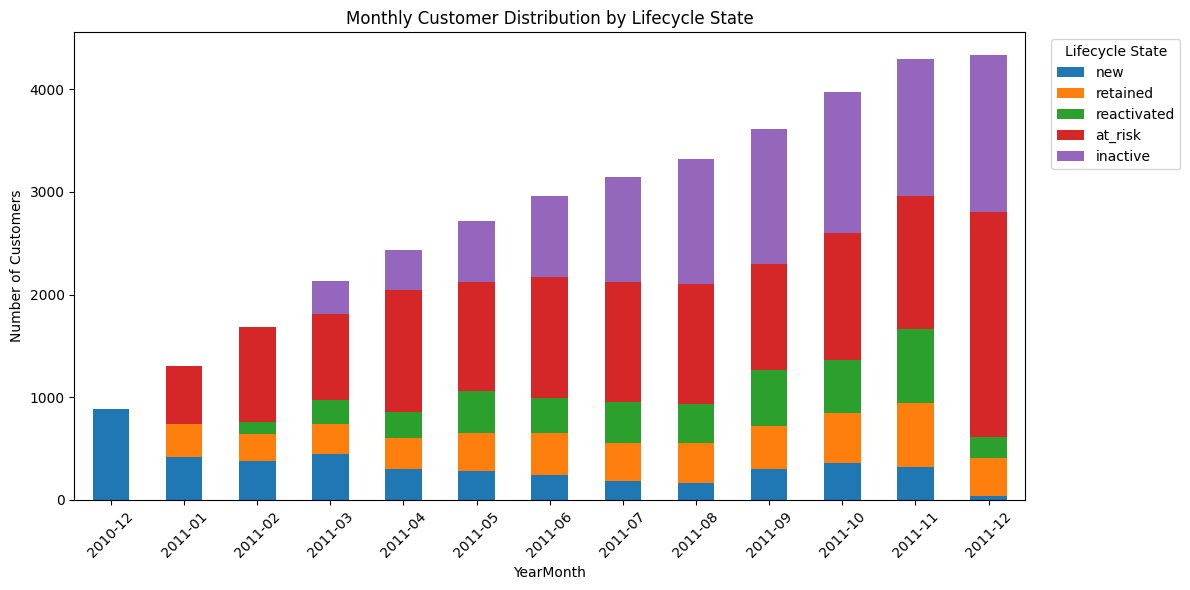

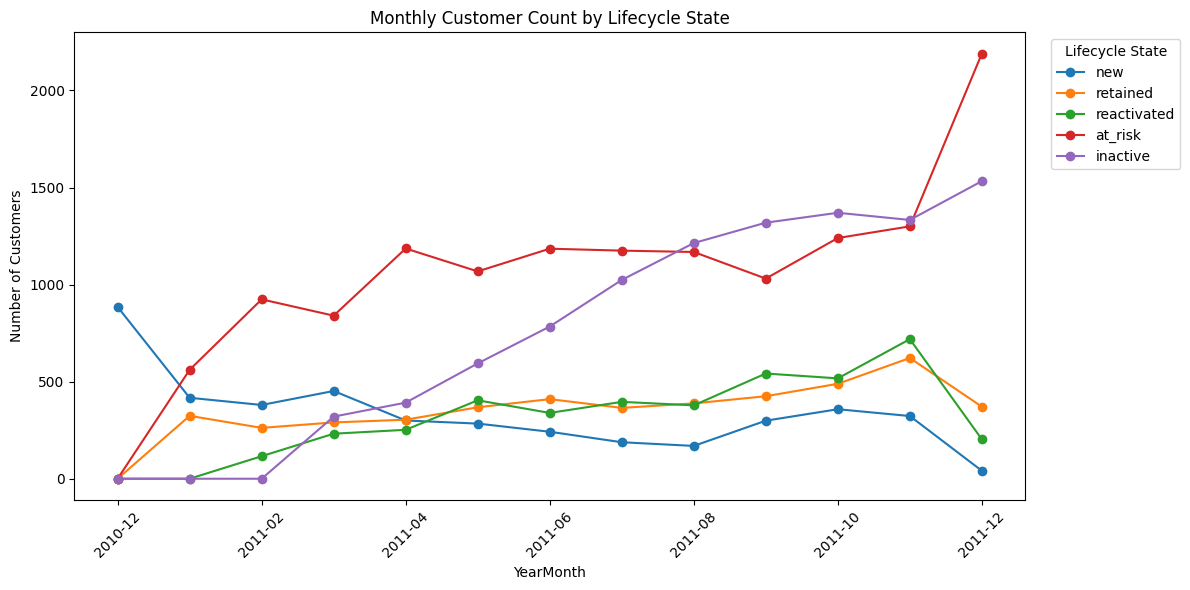

In [15]:
# ========== 10. Lifecycle distribution, visualization, and transitions ==========
# Pivot monthly customer counts by lifecycle state
state_dist_pivot = (
    state_dist.pivot(index="YearMonth", columns="lifecycle_state", values="customers")
    .fillna(0)
    .sort_index()
)

# Ensure all expected lifecycle states exist and follow the predefined order
for state in state_order:
    if state not in state_dist_pivot.columns:
        state_dist_pivot[state] = 0

state_dist_pivot = state_dist_pivot[state_order]

display(state_dist_pivot.head())

# Stacked bar chart: monthly customer composition by lifecycle state
state_dist_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Monthly Customer Distribution by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Lifecycle State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Line chart: monthly customer counts by lifecycle state
state_dist_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)
plt.title("Monthly Customer Count by Lifecycle State")
plt.xlabel("YearMonth")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Lifecycle State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


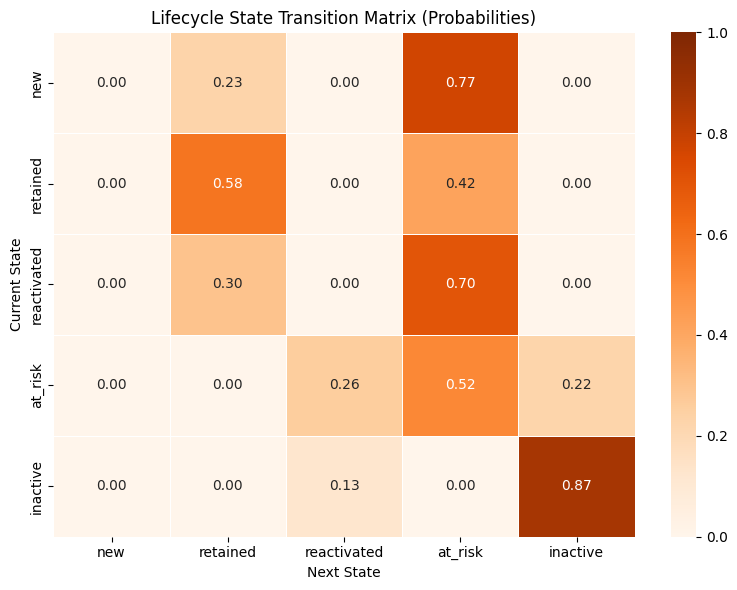

In [16]:
# ========== 10.1 Plot lifecycle transition probability heatmap ==========
import matplotlib.pyplot as plt
import seaborn as sns

transition_counts = transition_pivot.copy()

transition_probs = transition_counts.div(
    transition_counts.sum(axis=1).replace(0, np.nan),
    axis=0
).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    transition_probs,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=1
)
plt.title("Lifecycle State Transition Matrix (Probabilities)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()

## 5. Retention Analysis: Survival Analysis 
The problem addressed in this part is: 
- How long can a user "survive" from their first purchase?
- Which features significantly affect the risk of churn? 
Here, an approximate definition of non-contractual retail is used: If a customer does not make another purchase within a set window (for example, 90 days) after their last purchase, it is considered a churn event; otherwise, it is considered censored.

In [17]:
# ========== 11. Build survival-analysis data with calibrated churn window ==========
customer_orders = (
    order_level.groupby("CustomerID")
    .agg(
        first_purchase=("InvoiceDate", "min"),
        last_purchase=("InvoiceDate", "max"),
        n_orders=("InvoiceNo", "nunique"),
        total_revenue=("order_revenue", "sum"),
        avg_order_value=("order_revenue", "mean"),
        avg_items=("items", "mean"),
        avg_unique_skus=("unique_skus", "mean"),
        country=("Country", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    )
    .reset_index()
)

observation_end = order_level["InvoiceDate"].max()

# Use the empirical P90 interpurchase gap as the churn boundary
churn_window_days = gap_p90_days

customer_orders["days_since_last_purchase_to_obs_end"] = (
    observation_end - customer_orders["last_purchase"]
).dt.days

# Survival event: customer has been inactive longer than the calibrated churn window
customer_orders["event_observed"] = (
    customer_orders["days_since_last_purchase_to_obs_end"] > churn_window_days
).astype(int)

customer_orders["survival_end_date"] = np.where(
    customer_orders["event_observed"] == 1,
    customer_orders["last_purchase"],
    observation_end
)
customer_orders["survival_end_date"] = pd.to_datetime(customer_orders["survival_end_date"])

customer_orders["duration_days"] = (
    customer_orders["survival_end_date"] - customer_orders["first_purchase"]
).dt.days.clip(lower=1)

# First-order features for Cox PH
first_order = (
    order_level.sort_values("InvoiceDate")
    .groupby("CustomerID")
    .head(1)[["CustomerID", "order_revenue", "items", "unique_skus"]]
    .rename(columns={
        "order_revenue": "first_order_value",
        "items": "first_order_items",
        "unique_skus": "first_order_unique_skus"
    })
)

survival_df = customer_orders.merge(first_order, on="CustomerID", how="left")

print(f"Calibrated churn window (days): {churn_window_days}")
display(survival_df.head())

Calibrated churn window (days): 103


,CustomerID,first_purchase,last_purchase,n_orders,total_revenue,avg_order_value,avg_items,avg_unique_skus,country,days_since_last_purchase_to_obs_end,event_observed,survival_end_date,duration_days,first_order_value,first_order_items,first_order_unique_skus
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,74215.000000,1.00,United Kingdom,325,1,2011-01-18 10:01:00,1,77183.60,74215,1
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,615.714286,351.142857,26.00,Iceland,1,0,2011-12-09 12:50:00,366,711.79,319,31
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,449.310000,585.250000,6.75,Finland,74,0,2011-12-09 12:50:00,357,892.80,1254,13
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,1757.550000,631.000000,73.00,Italy,18,0,2011-12-09 12:50:00,18,1757.55,631,73
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197.000000,17.00,Norway,309,1,2011-02-02 16:01:00,1,334.40,197,17


### Kaplan-Meier Estimate

Summary statistics for first_order_value:


count     4338.000000
mean       425.319627
std       1290.168010
min          0.850000
25%        166.635000
50%        300.955000
75%        449.315000
90%        775.964000
95%       1083.862000
99%       2202.433500
max      77183.600000
Name: first_order_value, dtype: float64

Mean first_order_value: 425.32
Median first_order_value: 300.95
Skewness of first_order_value: 49.37


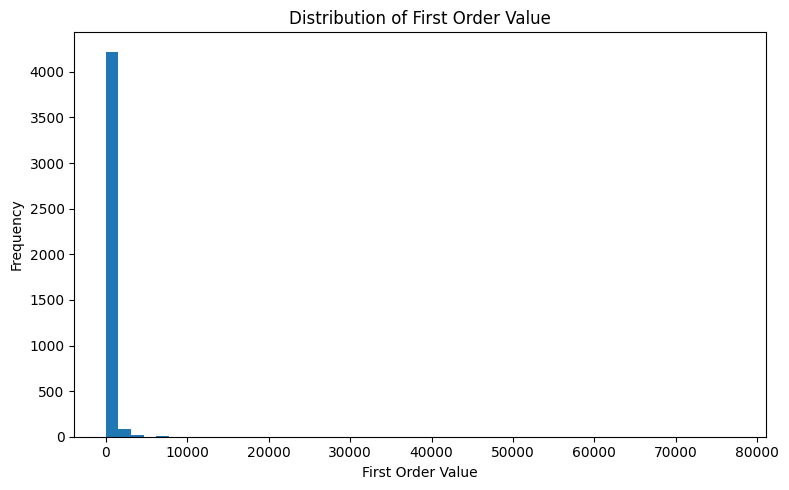

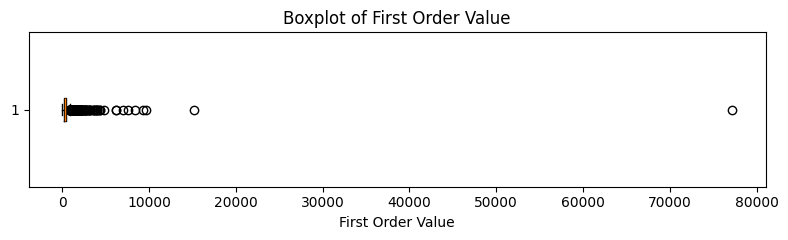

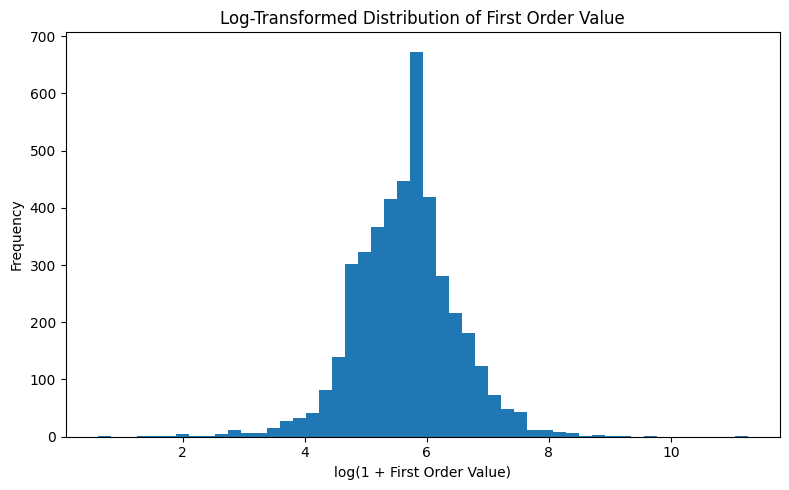

In [18]:
# ========== 12.0 Inspect the distribution of first-order value ==========
import matplotlib.pyplot as plt

# Summary statistics
first_order_stats = survival_df["first_order_value"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Summary statistics for first_order_value:")
display(first_order_stats)

mean_first_order = survival_df["first_order_value"].mean()
median_first_order = survival_df["first_order_value"].median()
skew_first_order = survival_df["first_order_value"].skew()

print(f"Mean first_order_value: {mean_first_order:.2f}")
print(f"Median first_order_value: {median_first_order:.2f}")
print(f"Skewness of first_order_value: {skew_first_order:.2f}")

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(survival_df["first_order_value"], bins=50)
plt.title("Distribution of First Order Value")
plt.xlabel("First Order Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(8, 2.5))
plt.boxplot(survival_df["first_order_value"], vert=False)
plt.title("Boxplot of First Order Value")
plt.xlabel("First Order Value")
plt.tight_layout()
plt.show()

# Optional: log-scale histogram for better visibility if the distribution is highly skewed
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(survival_df["first_order_value"]), bins=50)
plt.title("Log-Transformed Distribution of First Order Value")
plt.xlabel("log(1 + First Order Value)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

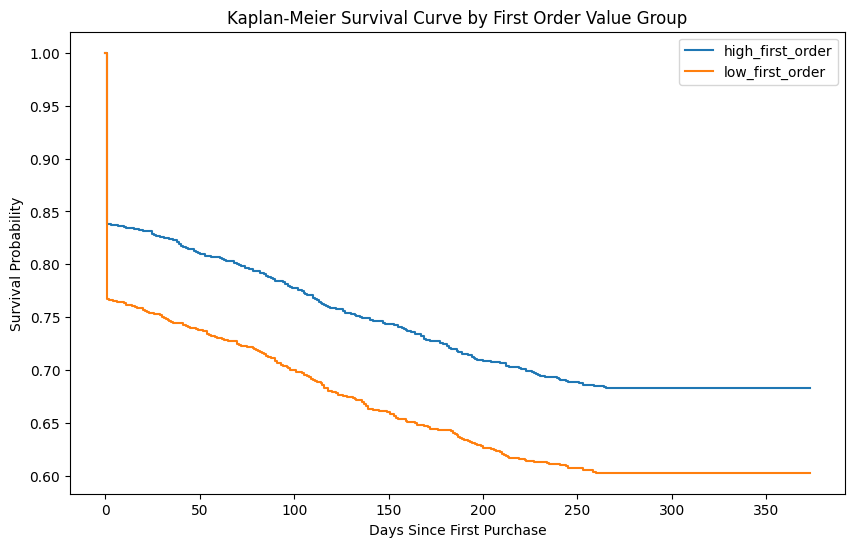

In [19]:
# ========== 12. Kaplan-Meier Survival Curve ==========
# Grouped by the amount of the first order
median_first_order = survival_df["first_order_value"].median()
survival_df["first_order_value_group"] = np.where(
    survival_df["first_order_value"] >= median_first_order, "high_first_order", "low_first_order"
)

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
for group_name, grp in survival_df.groupby("first_order_value_group"):
    kmf.fit(durations=grp["duration_days"], event_observed=grp["event_observed"], label=group_name)
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curve by First Order Value Group")
plt.xlabel("Days Since First Purchase")
plt.ylabel("Survival Probability")
plt.show()


In [20]:
# ========== 12.1 Log-rank test for survival difference by first-order-value group ==========
from lifelines.statistics import logrank_test

# Split the survival data into two groups
high_group = survival_df[survival_df["first_order_value_group"] == "high_first_order"]
low_group = survival_df[survival_df["first_order_value_group"] == "low_first_order"]

# Perform the log-rank test
logrank_result = logrank_test(
    durations_A=high_group["duration_days"],
    durations_B=low_group["duration_days"],
    event_observed_A=high_group["event_observed"],
    event_observed_B=low_group["event_observed"]
)

# Print the test results
print("Log-rank test comparing survival curves by first-order-value group")
print(f"Test statistic: {logrank_result.test_statistic:.4f}")
print(f"P-value: {logrank_result.p_value:.6f}")

# Optional interpretation
if logrank_result.p_value < 0.05:
    print("Result: The survival difference between the two groups is statistically significant.")
else:
    print("Result: The survival difference between the two groups is not statistically significant.")

Log-rank test comparing survival curves by first-order-value group
Test statistic: 33.0914
P-value: 0.000000
Result: The survival difference between the two groups is statistically significant.


### Cox PH

In [21]:
# ========== 13. Cox PH model with log transformation and standardization ==========
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

# ------------------------------------------
# Step 1: Select variables for Cox PH
# ------------------------------------------
cox_data_raw = survival_df[[
    "duration_days",
    "event_observed",
    "first_order_value",
    "first_order_items",
    "first_order_unique_skus",
    "n_orders",
    "total_revenue",
    "avg_order_value",
    "avg_unique_skus"
]].dropna().copy()

# ------------------------------------------
# Step 2: Apply log transformation to skewed monetary variables
# log1p(x) = log(1 + x), which is safe for zero values
# ------------------------------------------
cox_data_raw["log_first_order_value"] = np.log1p(cox_data_raw["first_order_value"])
cox_data_raw["log_total_revenue"] = np.log1p(cox_data_raw["total_revenue"])
cox_data_raw["log_avg_order_value"] = np.log1p(cox_data_raw["avg_order_value"])

# ------------------------------------------
# Step 3: Build the final modeling dataset
# Keep transformed monetary variables instead of raw monetary variables
# ------------------------------------------
cox_data = cox_data_raw[[
    "duration_days",
    "event_observed",
    "log_first_order_value",
    "first_order_items",
    "first_order_unique_skus",
    "n_orders",
    "log_total_revenue",
    "log_avg_order_value",
    "avg_unique_skus"
]].copy()

# ------------------------------------------
# Step 4: Standardize continuous covariates
# Do not standardize duration_days or event_observed
# ------------------------------------------
cox_features = [
    "log_first_order_value",
    "first_order_items",
    "first_order_unique_skus",
    "n_orders",
    "log_total_revenue",
    "log_avg_order_value",
    "avg_unique_skus"
]

scaler = StandardScaler()
cox_data[cox_features] = scaler.fit_transform(cox_data[cox_features])

# ------------------------------------------
# Step 5: Fit the Cox Proportional Hazards model
# A small penalizer can help numerical stability when features are correlated
# ------------------------------------------
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_data, duration_col="duration_days", event_col="event_observed")

# ------------------------------------------
# Step 6: Print model summary
# Coefficients are now interpreted as the effect of a one-standard-deviation increase
# in each transformed covariate on the hazard
# ------------------------------------------
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4338 total observations, 2996 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_observed'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 4338
number of events observed = 1342
   partial log-likelihood = -9987.47
         time fit was run = 2026-04-25 07:35:54 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
log_first_order_value    0.39      1.48      0.07            0.24            0.54                1.28                1.71
first_order_items        0.03      1.03      0.02           -0.00            0.07                1.00                1.07
first_order_unique_skus  0.04      1.04      0.07           -0.10            0.18                0.91                1.20
n_orders                -0.68      0.51      0.13           -0.94           -0.42                0.39                0.65
log_total_revenue       -1.87      0.15      0.08           -2.03           -1.72                0.13                0.18
log_avg_order_value      0.65      1.91      0.08            0.50            0.80                1.64                2.22
avg_unique_skus         -0.20      0.82      0.07           -0.34           -0.06                0.72                0.94

                         cmp to      z      p  -log2(p)
covariate                                              
log_first_order_value      0.00   5.22 <0.005     22.45
first_order_items          0.00   1.94   0.05      4.26
first_order_unique_skus    0.00   0.60   0.55      0.87
n_orders                   0.00  -5.20 <0.005     22.29
log_total_revenue          0.00 -23.96 <0.005    419.16
log_avg_order_value        0.00   8.42 <0.005     54.56
avg_unique_skus            0.00  -2.86 <0.005      7.89
---
Concordance = 0.86
Partial AIC = 19988.94
log-likelihood ratio test = 1689.81 on 7 df
-log2(p) of ll-ratio test = inf

## 6. Retention Prediction: Machine Learning 
Taking "customer-month panel" as the sample, predict whether the customer will make a purchase in the following month. 
### Model Significance
- Generate a list of high-risk customers with high churn rates
- Identify the key behavioral characteristics that affect repeat purchases
- Provide a basis for recall efforts and budget allocation

In [22]:
# ========== 14. Retention prediction with improved feature engineering ==========
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)
from sklearn.linear_model import LogisticRegression
# ------------------------------------------
# Step 1: Build next-month retention label
# ------------------------------------------
retention_panel = panel.copy()

retention_panel["retained_next_month"] = (
    retention_panel.groupby("CustomerID")["is_active"].shift(-1)
)

# Remove rows without next-month label
retention_panel = retention_panel.dropna(subset=["retained_next_month"]).copy()
retention_panel["retained_next_month"] = retention_panel["retained_next_month"].astype(int)

# ------------------------------------------
# Step 2: Create cumulative depth features up to current month
# Use only information available at the current month
# ------------------------------------------
g = retention_panel.groupby("CustomerID")

retention_panel["cum_orders_to_date"] = g["month_orders"].cumsum()
retention_panel["cum_revenue_to_date"] = g["month_revenue"].cumsum()
retention_panel["cum_items_to_date"] = g["month_items"].cumsum()
retention_panel["cum_active_months_to_date"] = g["is_active"].cumsum()

# Average order depth up to current month
retention_panel["cum_orders_before"] = retention_panel["cum_orders_to_date"] - retention_panel["month_orders"]
retention_panel["cum_revenue_before"] = retention_panel["cum_revenue_to_date"] - retention_panel["month_revenue"]
retention_panel["cum_items_before"] = retention_panel["cum_items_to_date"] - retention_panel["month_items"]
retention_panel["cum_active_months_before"] = (
    retention_panel["cum_active_months_to_date"] - retention_panel["is_active"]
)

# ------------------------------------------
# Step 3: Create trend features from rolling windows
# These features compare recent behavior vs medium-term behavior
# ------------------------------------------
retention_panel["orders_trend_3m_vs_6m"] = (
    retention_panel["orders_last_3m"] - retention_panel["orders_last_6m"] / 2
)
retention_panel["revenue_trend_3m_vs_6m"] = (
    retention_panel["revenue_last_3m"] - retention_panel["revenue_last_6m"] / 2
)
retention_panel["active_months_trend_3m_vs_6m"] = (
    retention_panel["active_months_last_3m"] - retention_panel["active_months_last_6m"] / 2
)

# ------------------------------------------
# Step 4: Log-transform skewed monetary features
# ------------------------------------------
monetary_cols = [
    "month_revenue",
    "avg_order_value",
    "cum_revenue_before",
    "revenue_last_3m",
    "revenue_last_6m"
]

for col in monetary_cols:
    retention_panel[f"log_{col}"] = np.log1p(retention_panel[col])

# ------------------------------------------
# Step 5: Keep a clean modeling dataset
# Include lifecycle_state as a categorical feature
# ------------------------------------------
model_cols = [
    "CustomerID",
    "YearMonth",
    "month",
    "retained_next_month",
    "is_active",
    "lifecycle_state",

    # Current-month behavior
    "month_orders",
    "month_revenue",
    "month_items",
    "month_unique_skus",
    "avg_order_value",
    "log_month_revenue",
    "log_avg_order_value",

    # Recency and lifecycle depth
    "prev_active",
    "days_since_last_purchase",
    "customer_age_months",
    "cum_orders_before",
    "log_cum_revenue_before",
    "cum_items_before",
    "cum_active_months_before",

    # Rolling behavior
    "orders_last_3m",
    "active_months_last_3m",
    "log_revenue_last_3m",
    "orders_last_6m",
    "active_months_last_6m",
    "log_revenue_last_6m",

    # Trend features
    "orders_trend_3m_vs_6m",
    "revenue_trend_3m_vs_6m",
    "active_months_trend_3m_vs_6m"
]

retention_data = retention_panel[model_cols].copy()

# Drop rows before the customer has enough history if desired
retention_data = retention_data[retention_data["customer_age_months"] >= 1].copy()

display(retention_data.head())

# ------------------------------------------
# Step 6: Define train/test split by time
# Use the latest complete month as test set
# ------------------------------------------
all_months_sorted = sorted(retention_data["YearMonth"].unique())
test_month = all_months_sorted[-1]

train_data = retention_data[retention_data["YearMonth"] < test_month].copy()
test_data = retention_data[retention_data["YearMonth"] == test_month].copy()

print(f"Train months: {train_data['YearMonth'].min()} to {train_data['YearMonth'].max()}")
print(f"Test month: {test_month}")
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# ------------------------------------------
# Step 7: Separate features and target
# ------------------------------------------
target_col = "retained_next_month"

feature_cols = [
    "is_active",
    "lifecycle_state",
    "month_orders",
    "month_items",
    "month_unique_skus",
    "log_month_revenue",
    "log_avg_order_value",
    "prev_active",
    "days_since_last_purchase",
    "customer_age_months",
    "cum_orders_before",
    "log_cum_revenue_before",
    "cum_items_before",
    "cum_active_months_before",
    "orders_last_3m",
    "active_months_last_3m",
    "log_revenue_last_3m",
    "orders_last_6m",
    "active_months_last_6m",
    "log_revenue_last_6m",
    "orders_trend_3m_vs_6m",
    "revenue_trend_3m_vs_6m",
    "active_months_trend_3m_vs_6m"
]

X_train = train_data[feature_cols].copy()
y_train = train_data[target_col].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data[target_col].copy()

# ------------------------------------------
# Step 8: Define numeric and categorical columns
# ------------------------------------------
categorical_features = ["lifecycle_state"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

# ------------------------------------------
# Step 9: Preprocessing
# - Median imputation for numeric variables
# - Most frequent imputation for categorical variables
# - Standardization for Logistic Regression pipeline
# - One-hot encoding for lifecycle_state
# ------------------------------------------
from sklearn.preprocessing import OneHotEncoder

numeric_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------
# Step 10: Train Logistic Regression
# ------------------------------------------
logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logit_model.fit(X_train, y_train)

logit_test_proba = logit_model.predict_proba(X_test)[:, 1]
logit_test_pred = (logit_test_proba >= 0.5).astype(int)

# ------------------------------------------
# Step 11: Train XGBoost
# ------------------------------------------
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_proba >= 0.5).astype(int)

# ------------------------------------------
# Step 12: Calibrate XGBoost probabilities
# ------------------------------------------
xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_model,
    method="isotonic",
    cv=3
)

xgb_calibrated.fit(X_train, y_train)

xgb_cal_test_proba = xgb_calibrated.predict_proba(X_test)[:, 1]
xgb_cal_test_pred = (xgb_cal_test_proba >= 0.5).astype(int)

# ------------------------------------------
# Step 13: Evaluation helper
# ------------------------------------------
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name):
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    brier = brier_score_loss(y_true, y_proba)

    print(f"\n===== {model_name} =====")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Brier score: {brier:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

evaluate_binary_classifier(y_test, logit_test_pred, logit_test_proba, "Logistic Regression")
evaluate_binary_classifier(y_test, xgb_test_pred, xgb_test_proba, "XGBoost")
evaluate_binary_classifier(y_test, xgb_cal_test_pred, xgb_cal_test_proba, "Calibrated XGBoost")

# ------------------------------------------
# Step 14: Top-K capture analysis
# This evaluates how many actual retained customers are captured in the top predicted group
# ------------------------------------------
def top_k_capture_rate(y_true, y_proba, k=0.1):
    df_eval = pd.DataFrame({
        "y_true": y_true,
        "y_proba": y_proba
    }).sort_values("y_proba", ascending=False).reset_index(drop=True)

    top_n = max(1, int(len(df_eval) * k))
    top_df = df_eval.head(top_n)

    capture_rate = top_df["y_true"].sum() / df_eval["y_true"].sum()
    precision_at_k = top_df["y_true"].mean()

    return pd.Series({
        "top_fraction": k,
        "top_n": top_n,
        "capture_rate": capture_rate,
        "precision_at_k": precision_at_k
    })

topk_logit = top_k_capture_rate(y_test.values, logit_test_proba, k=0.1)
topk_xgb = top_k_capture_rate(y_test.values, xgb_test_proba, k=0.1)
topk_xgb_cal = top_k_capture_rate(y_test.values, xgb_cal_test_proba, k=0.1)

topk_summary = pd.DataFrame({
    "Logistic": topk_logit,
    "XGBoost": topk_xgb,
    "Calibrated_XGBoost": topk_xgb_cal
})

print("\nTop-10% capture summary:")
display(topk_summary)

# ------------------------------------------
# Step 15: Build risk-scoring output for the test month
# Retention probability -> churn risk score
# ------------------------------------------
scoring_output = test_data[[
    "CustomerID",
    "YearMonth",
    "month",
    "lifecycle_state",
    "days_since_last_purchase",
    "month_orders",
    "month_revenue"
]].copy()

scoring_output["retention_prob_logit"] = logit_test_proba
scoring_output["retention_prob_xgb"] = xgb_test_proba
scoring_output["retention_prob_xgb_calibrated"] = xgb_cal_test_proba

scoring_output["churn_risk_logit"] = 1 - scoring_output["retention_prob_logit"]
scoring_output["churn_risk_xgb"] = 1 - scoring_output["retention_prob_xgb"]
scoring_output["churn_risk_xgb_calibrated"] = 1 - scoring_output["retention_prob_xgb_calibrated"]

scoring_output = scoring_output.sort_values(
    "churn_risk_xgb_calibrated",
    ascending=False
).reset_index(drop=True)

display(scoring_output.head(20))

# ------------------------------------------
# Step 16: Optional feature importance for XGBoost
# ------------------------------------------
xgb_estimator = xgb_model.named_steps["classifier"]
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

feature_names_num = numeric_features
feature_names_cat = list(
    xgb_preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = feature_names_num + feature_names_cat

xgb_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": xgb_estimator.feature_importances_
}).sort_values("importance", ascending=False)

display(xgb_importance.head(20))

,CustomerID,YearMonth,month,retained_next_month,is_active,lifecycle_state,month_orders,month_revenue,month_items,month_unique_skus,avg_order_value,log_month_revenue,log_avg_order_value,prev_active,days_since_last_purchase,customer_age_months,cum_orders_before,log_cum_revenue_before,cum_items_before,cum_active_months_before,orders_last_3m,active_months_last_3m,log_revenue_last_3m,orders_last_6m,active_months_last_6m,log_revenue_last_6m,orders_trend_3m_vs_6m,revenue_trend_3m_vs_6m,active_months_trend_3m_vs_6m
1,12346,2011-02,2011-02-01,0,0,at_risk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,40,1,1.0,11.253955,74215.0,1,1.0,1.0,11.253955,1.0,1.0,11.253955,0.5,38591.8,0.5
2,12346,2011-03,2011-03-01,0,0,at_risk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71,2,1.0,11.253955,74215.0,1,1.0,1.0,11.253955,1.0,1.0,11.253955,0.5,38591.8,0.5
3,12346,2011-04,2011-04-01,0,0,at_risk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,3,1.0,11.253955,74215.0,1,1.0,1.0,11.253955,1.0,1.0,11.253955,0.5,38591.8,0.5
4,12346,2011-05,2011-05-01,0,0,inactive,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,132,4,1.0,11.253955,74215.0,1,0.0,0.0,0.000000,1.0,1.0,11.253955,-0.5,-38591.8,-0.5
5,12346,2011-06,2011-06-01,0,0,inactive,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,162,5,1.0,11.253955,74215.0,1,0.0,0.0,0.000000,1.0,1.0,11.253955,-0.5,-38591.8,-0.5


Train months: 2011-01 to 2011-10
Test month: 2011-11
Train size: 24196
Test size: 3974

===== Logistic Regression =====
ROC-AUC: 0.7756
PR-AUC: 0.4408
Precision: 0.2498
Recall: 0.7584
F1-score: 0.3759
Brier score: 0.2354

Confusion Matrix:
[[2211 1225]
 [ 130  408]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.77      3436
           1       0.25      0.76      0.38       538

    accuracy                           0.66      3974
   macro avg       0.60      0.70      0.57      3974
weighted avg       0.85      0.66      0.71      3974


===== XGBoost =====
ROC-AUC: 0.7796
PR-AUC: 0.4541
Precision: 0.3730
Recall: 0.5762
F1-score: 0.4529
Brier score: 0.1483

Confusion Matrix:
[[2915  521]
 [ 228  310]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      3436
           1       0.37      0.58      0.45       538

    accuracy              

,Logistic,XGBoost,Calibrated_XGBoost
top_fraction,0.100000,0.100000,0.100000
top_n,397.000000,397.000000,397.000000
capture_rate,0.371747,0.390335,0.384758
precision_at_k,0.503778,0.528967,0.521411


,CustomerID,YearMonth,month,lifecycle_state,days_since_last_purchase,month_orders,month_revenue,retention_prob_logit,retention_prob_xgb,retention_prob_xgb_calibrated,churn_risk_logit,churn_risk_xgb,churn_risk_xgb_calibrated
0,16765,2011-11,2011-11-01,inactive,284,0.0,0.00,0.155690,0.062393,0.057389,0.844310,0.937607,0.942611
1,15940,2011-11,2011-11-01,inactive,301,0.0,0.00,0.159216,0.060967,0.057389,0.840784,0.939033,0.942611
2,12401,2011-11,2011-11-01,inactive,293,0.0,0.00,0.190707,0.064684,0.062259,0.809293,0.935316,0.937741
3,16349,2011-11,2011-11-01,inactive,280,0.0,0.00,0.171455,0.061997,0.062259,0.828545,0.938003,0.937741
4,16078,2011-11,2011-11-01,inactive,273,0.0,0.00,0.187813,0.077614,0.062259,0.812187,0.922386,0.937741
5,13185,2011-11,2011-11-01,inactive,257,0.0,0.00,0.181843,0.077954,0.068652,0.818157,0.922046,0.931348
6,12438,2011-11,2011-11-01,reactivated,4,1.0,2016.78,0.395395,0.061996,0.077967,0.604605,0.938004,0.922033
7,17536,2011-11,2011-11-01,inactive,167,0.0,0.00,0.190362,0.063406,0.078386,0.809638,0.936594,0.921614
8,15098,2011-11,2011-11-01,inactive,172,0.0,0.00,0.531064,0.091735,0.083158,0.468936,0.908265,0.916842
9,17995,2011-11,2011-11-01,inactive,271,0.0,0.00,0.185340,0.077723,0.087995,0.814660,0.922277,0.912005


,feature,importance
16,orders_last_6m,0.284819
9,cum_orders_before,0.098114
13,orders_last_3m,0.097674
14,active_months_last_3m,0.094731
25,lifecycle_state_retained,0.085308
0,is_active,0.054869
23,lifecycle_state_inactive,0.042006
1,month_orders,0.026679
15,log_revenue_last_3m,0.024975
12,cum_active_months_before,0.023929


## 6. CLV ：BG/NBD + Gamma-Gamma vs XGBoost

### Objective
Compare the two methods within the framework of "time segmentation": 
1. **Probability Model**
- BG/NBD: Predicts the number of future window purchases
- Gamma-Gamma: Predicts the future order amount
- Combining the two gives the future CLV (Customer Lifetime Value) 
2. **Machine Learning Model**
- Directly predict future income for 30 days / 60 days 
### Time Segmentation Logic
Take "the last 30 days as the test window" as an example: 
- `calibration_end = observation_end - 30 days`
- Train / fit using data within the calibration period
- Use the actual revenue in the holdout period (the last 30 days) as the evaluation target
# Group by the amount of the first order


In [23]:
# ========== 18. CLV settings ==========
# This section compares:
# 1) BG/NBD + Gamma-Gamma
# 2) XGBoost regression
# under the same time-based holdout framework.

# Holdout window for evaluation
holdout_days = 30   # change to 60 for another comparison

# Production CLV horizon
clv_horizon_days = 180   # e.g. future 180-day CLV

# Annual discount rate for present-value interpretation
annual_discount_rate = 0.10

# Convert annual discount rate into a daily discount rate
daily_discount_rate = (1 + annual_discount_rate) ** (1 / 365) - 1

observation_end = order_level["InvoiceDate"].max().normalize()
calibration_end = observation_end - pd.Timedelta(days=holdout_days)

print("Observation end:", observation_end)
print("Calibration end:", calibration_end)
print("Holdout window days:", holdout_days)
print("CLV horizon days:", clv_horizon_days)
print("Annual discount rate:", annual_discount_rate)
print("Daily discount rate:", round(daily_discount_rate, 8))

Observation end: 2011-12-09 00:00:00
Calibration end: 2011-11-09 00:00:00
Holdout window days: 30
CLV horizon days: 180
Annual discount rate: 0.1
Daily discount rate: 0.00026116


In [24]:
# ========== 19. Generate month-end rolling cutoffs ==========
from pandas.tseries.offsets import MonthEnd

def generate_month_end_cutoffs(order_level, holdout_days=30, min_train_days=180):
    """
    Generate month-end cutoffs for rolling CLV backtesting.
    Month-end cutoffs are preferred because the customer-month panel
    is month-based, and using month-end reduces leakage risk.
    """
    min_date = order_level["InvoiceDate"].min().normalize()
    max_date = order_level["InvoiceDate"].max().normalize()

    first_valid_date = min_date + pd.Timedelta(days=min_train_days)
    last_valid_cutoff = max_date - pd.Timedelta(days=holdout_days)

    # Generate all month ends within the valid range
    month_ends = pd.date_range(
        start=first_valid_date,
        end=last_valid_cutoff,
        freq="M"
    )

    return list(month_ends)

cutoffs = generate_month_end_cutoffs(
    order_level=order_level,
    holdout_days=holdout_days,
    min_train_days=180
)

print("Number of cutoffs:", len(cutoffs))
print("First 5 cutoffs:", cutoffs[:5])
print("Last 3 cutoffs:", cutoffs[-3:])

Number of cutoffs: 6
First 5 cutoffs: [Timestamp('2011-05-31 00:00:00'), Timestamp('2011-06-30 00:00:00'), Timestamp('2011-07-31 00:00:00'), Timestamp('2011-08-31 00:00:00'), Timestamp('2011-09-30 00:00:00')]
Last 3 cutoffs: [Timestamp('2011-08-31 00:00:00'), Timestamp('2011-09-30 00:00:00'), Timestamp('2011-10-31 00:00:00')]


In [25]:
# ========== 20. Helper for panel snapshot before cutoff ==========
def get_panel_snapshot_before_cutoff(panel, cutoff):
    """
    Use the last fully completed month before the cutoff as the customer snapshot.
    This avoids leakage from using a month that is still in progress at the cutoff date.
    """
    snapshot_month = (cutoff.to_period("M") - 1).to_timestamp()

    snapshot = panel[panel["month"] == snapshot_month].copy()

    keep_cols = [
        "CustomerID",
        "month",
        "is_active",
        "lifecycle_state",
        "days_since_last_purchase",
        "customer_age_months",
        "cum_active_months_before",
        "orders_last_3m",
        "revenue_last_3m",
        "active_months_last_3m",
        "orders_last_6m",
        "revenue_last_6m",
        "active_months_last_6m"
    ]

    keep_cols = [c for c in keep_cols if c in snapshot.columns]
    snapshot = snapshot[keep_cols].copy()

    if "lifecycle_state" in snapshot.columns:
        snapshot["lifecycle_state"] = snapshot["lifecycle_state"].astype(str)

    return snapshot

In [26]:
# ========== 21. BG/NBD + Gamma-Gamma helper ==========
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


def fit_bgnbd_gg_and_score(order_level, cutoff, holdout_days=30, penalizer=0.05):
    """
    Fit BG/NBD + Gamma-Gamma before cutoff and evaluate against the holdout window.
    """
    calib_tx = order_level[order_level["InvoiceDate"] <= cutoff].copy()
    holdout_tx = order_level[
        (order_level["InvoiceDate"] > cutoff) &
        (order_level["InvoiceDate"] <= cutoff + pd.Timedelta(days=holdout_days))
    ].copy()

    if calib_tx.empty:
        return None, None, None

    eligible_customers = calib_tx["CustomerID"].unique()
    holdout_tx = holdout_tx[holdout_tx["CustomerID"].isin(eligible_customers)].copy()

    summary = summary_data_from_transaction_data(
        transactions=calib_tx,
        customer_id_col="CustomerID",
        datetime_col="InvoiceDate",
        monetary_value_col="order_revenue",
        observation_period_end=cutoff,
        freq="D"
    ).reset_index()

    summary = summary.rename(columns={"customer_id": "CustomerID"})

    # Fit BG/NBD
    bgf = BetaGeoFitter(penalizer_coef=penalizer)
    bgf.fit(summary["frequency"], summary["recency"], summary["T"])

    summary["pred_orders_holdout"] = bgf.conditional_expected_number_of_purchases_up_to_time(
        holdout_days,
        summary["frequency"],
        summary["recency"],
        summary["T"]
    )
    summary["prob_alive"] = bgf.conditional_probability_alive(
        summary["frequency"],
        summary["recency"],
        summary["T"]
    )

    # Gamma-Gamma can only be fit on repeat buyers with positive monetary value
    mask = (summary["frequency"] > 0) & (summary["monetary_value"] > 0)

    gg_diagnostics = {}
    if mask.sum() > 0:
        ggf = GammaGammaFitter(penalizer_coef=0.01)
        ggf.fit(summary.loc[mask, "frequency"], summary.loc[mask, "monetary_value"])

        # Check the rough independence assumption between frequency and monetary value
        corr = summary.loc[mask, ["frequency", "monetary_value"]].corr().iloc[0, 1]
        gg_diagnostics["freq_monetary_corr"] = corr

        summary["pred_avg_order_value"] = np.nan
        summary.loc[mask, "pred_avg_order_value"] = ggf.conditional_expected_average_profit(
            summary.loc[mask, "frequency"],
            summary.loc[mask, "monetary_value"]
        )
    else:
        summary["pred_avg_order_value"] = np.nan
        gg_diagnostics["freq_monetary_corr"] = np.nan

    # Fallback for one-time buyers
    global_avg_order_value = calib_tx["order_revenue"].mean()
    summary["pred_avg_order_value"] = summary["pred_avg_order_value"].fillna(global_avg_order_value)

    # Holdout revenue prediction
    summary["pred_revenue_bgnbd_gg"] = (
        summary["pred_orders_holdout"] * summary["pred_avg_order_value"]
    )

    # Actual holdout outcome
    actual_holdout = (
        holdout_tx.groupby("CustomerID")
        .agg(
            actual_holdout_orders=("InvoiceNo", "nunique"),
            actual_holdout_revenue=("order_revenue", "sum")
        )
        .reset_index()
    )

    eval_df = summary.merge(actual_holdout, on="CustomerID", how="left")
    eval_df["actual_holdout_orders"] = eval_df["actual_holdout_orders"].fillna(0)
    eval_df["actual_holdout_revenue"] = eval_df["actual_holdout_revenue"].fillna(0)
    eval_df["cutoff"] = cutoff
    metrics = {
    "cutoff": cutoff,
    "model": "BG/NBD + GG",
    "holdout_days": holdout_days,
    "MAE": mean_absolute_error(eval_df["actual_holdout_revenue"], eval_df["pred_revenue_bgnbd_gg"]),
    "RMSE": np.sqrt(mean_squared_error(eval_df["actual_holdout_revenue"], eval_df["pred_revenue_bgnbd_gg"])),
    "R2": r2_score(eval_df["actual_holdout_revenue"], eval_df["pred_revenue_bgnbd_gg"]),
    "freq_monetary_corr": gg_diagnostics["freq_monetary_corr"]
}

 
    return eval_df, metrics, bgf

In [27]:
# ========== 22. XGBoost CLV feature builder ==========
def build_customer_features_for_clv(order_level, panel, cutoff, holdout_days=30):
    """
    Build customer-level features before cutoff and future holdout revenue label.
    This function combines:
    1) transaction-based CLV features
    2) snapshot features from the customer-month panel
    """
    calib_tx = order_level[order_level["InvoiceDate"] <= cutoff].copy()
    holdout_tx = order_level[
        (order_level["InvoiceDate"] > cutoff) &
        (order_level["InvoiceDate"] <= cutoff + pd.Timedelta(days=holdout_days))
    ].copy()

    if calib_tx.empty:
        return None

    features = (
        calib_tx.groupby("CustomerID")
        .agg(
            calib_orders=("InvoiceNo", "nunique"),
            calib_revenue=("order_revenue", "sum"),
            calib_avg_order_value=("order_revenue", "mean"),
            calib_avg_items=("items", "mean"),
            calib_avg_unique_skus=("unique_skus", "mean"),
            calib_first_purchase=("InvoiceDate", "min"),
            calib_last_purchase=("InvoiceDate", "max")
        )
        .reset_index()
    )

    features["recency_days"] = (
        cutoff - features["calib_last_purchase"].dt.normalize()
    ).dt.days.clip(lower=0)

    features["customer_age_days"] = (
        cutoff - features["calib_first_purchase"].dt.normalize()
    ).dt.days.clip(lower=1)

    features["avg_days_between_orders_proxy"] = (
        features["customer_age_days"] / features["calib_orders"].replace(0, 1)
    )

    # Recent rolling windows from transaction data
    for w in [30, 60, 90]:
        tmp = calib_tx[calib_tx["InvoiceDate"] > cutoff - pd.Timedelta(days=w)].copy()
        agg = (
            tmp.groupby("CustomerID")
            .agg(
                **{
                    f"orders_last_{w}d": ("InvoiceNo", "nunique"),
                    f"revenue_last_{w}d": ("order_revenue", "sum"),
                    f"avg_order_value_last_{w}d": ("order_revenue", "mean")
                }
            )
            .reset_index()
        )
        features = features.merge(agg, on="CustomerID", how="left")

    # Merge panel-based snapshot features from the last fully observed month
    panel_snapshot = get_panel_snapshot_before_cutoff(panel, cutoff)
    features = features.merge(
        panel_snapshot.drop(columns=["month"], errors="ignore"),
        on="CustomerID",
        how="left"
    )

    # Holdout target
    target = (
        holdout_tx.groupby("CustomerID")
        .agg(
            target_holdout_revenue=("order_revenue", "sum"),
            target_holdout_orders=("InvoiceNo", "nunique")
        )
        .reset_index()
    )

    features = features.merge(target, on="CustomerID", how="left")
    features["target_holdout_revenue"] = features["target_holdout_revenue"].fillna(0)
    features["target_holdout_orders"] = features["target_holdout_orders"].fillna(0)

    # Log-transform skewed monetary variables
    monetary_cols = [
        "calib_revenue",
        "calib_avg_order_value",
        "revenue_last_30d",
        "revenue_last_60d",
        "revenue_last_90d",
        "avg_order_value_last_30d",
        "avg_order_value_last_60d",
        "avg_order_value_last_90d"
    ]

    for col in monetary_cols:
        if col in features.columns:
            features[f"log_{col}"] = np.log1p(features[col].fillna(0))

    # Trend features
    if {"orders_last_30d", "orders_last_90d"}.issubset(features.columns):
        features["orders_trend_30_vs_90"] = features["orders_last_30d"].fillna(0) - features["orders_last_90d"].fillna(0) / 3

    if {"revenue_last_30d", "revenue_last_90d"}.issubset(features.columns):
        features["revenue_trend_30_vs_90"] = features["revenue_last_30d"].fillna(0) - features["revenue_last_90d"].fillna(0) / 3

    # Fill remaining numeric missing values with 0
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    features[numeric_cols] = features[numeric_cols].fillna(0)

    # Fill missing categorical values
    if "lifecycle_state" in features.columns:
        features["lifecycle_state"] = features["lifecycle_state"].fillna("missing").astype(str)

    features["cutoff"] = cutoff

    return features

In [28]:
# ========== 23. Rolling XGBoost backtest ==========
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rolling_xgb_backtest(order_level, panel, cutoffs, holdout_days=30, min_train_windows=3):
    """
    Rolling backtest for XGBoost CLV prediction.
    No random split is used.
    Earlier cutoffs are used as training windows, and the current cutoff is used as test.
    """
    feature_frames = []

    for cutoff in cutoffs:
        feat = build_customer_features_for_clv(order_level, panel, cutoff, holdout_days=holdout_days)
        if feat is not None and not feat.empty:
            feature_frames.append(feat)

    if len(feature_frames) == 0:
        return None, None, None

    all_features = pd.concat(feature_frames, ignore_index=True, sort=False)

    # One-hot encode lifecycle_state if available
    if "lifecycle_state" in all_features.columns:
        all_features = pd.get_dummies(all_features, columns=["lifecycle_state"], drop_first=False)

    all_features = all_features.fillna(0)

    results = []
    pred_frames = []
    feature_importance_frames = []

    valid_cutoffs = sorted(all_features["cutoff"].unique())

    for i, current_cutoff in enumerate(valid_cutoffs):
        if i < min_train_windows:
            continue

        train_cutoffs = valid_cutoffs[:i]
        test_cutoff = current_cutoff

        train_df = all_features[all_features["cutoff"].isin(train_cutoffs)].copy()
        test_df = all_features[all_features["cutoff"] == test_cutoff].copy()

        exclude_cols = [
            "CustomerID",
            "calib_first_purchase",
            "calib_last_purchase",
            "target_holdout_revenue",
            "target_holdout_orders",
            "cutoff"
        ]
        feature_cols = [c for c in all_features.columns if c not in exclude_cols]

        X_train = train_df[feature_cols]
        y_train = train_df["target_holdout_revenue"]

        X_test = test_df[feature_cols]
        y_test = test_df["target_holdout_revenue"]

        model = XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        result = {
            "cutoff": test_cutoff,
            "model": "XGBoost",
            "holdout_days": holdout_days,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)
        }
        results.append(result)

        pred_frame = test_df[["CustomerID", "target_holdout_revenue", "target_holdout_orders"]].copy()
        pred_frame["pred_revenue_xgb"] = pred
        pred_frame["cutoff"] = test_cutoff
        pred_frames.append(pred_frame)

        fi = pd.DataFrame({
            "feature": feature_cols,
            "importance": model.feature_importances_,
            "cutoff": test_cutoff
        }).sort_values("importance", ascending=False)
        feature_importance_frames.append(fi)

    results_df = pd.DataFrame(results)
    preds_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()
    fi_df = pd.concat(feature_importance_frames, ignore_index=True) if feature_importance_frames else pd.DataFrame()

    return results_df, preds_df, fi_df

In [29]:
# ========== 24. Rolling BG/NBD + GG backtest ==========
def rolling_bgnbd_backtest(order_level, cutoffs, holdout_days=30):
    results = []
    pred_frames = []

    for cutoff in cutoffs:
        eval_df, metrics, _ = fit_bgnbd_gg_and_score(
            order_level=order_level,
            cutoff=cutoff,
            holdout_days=holdout_days
        )
        if eval_df is not None:
            results.append(metrics)
            pred_frames.append(eval_df)

    results_df = pd.DataFrame(results)
    preds_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

    return results_df, preds_df

In [30]:
# ========== 25. Run rolling CLV comparison ==========
bgnbd_results, bgnbd_preds = rolling_bgnbd_backtest(
    order_level=order_level,
    cutoffs=cutoffs,
    holdout_days=holdout_days
)

xgb_results, xgb_preds, xgb_feature_importance = rolling_xgb_backtest(
    order_level=order_level,
    panel=panel,
    cutoffs=cutoffs,
    holdout_days=holdout_days,
    min_train_windows=3
)

display(bgnbd_results)
display(xgb_results)

,cutoff,model,holdout_days,MAE,RMSE,R2,freq_monetary_corr
0,2011-05-31,BG/NBD + GG,30,196.969649,862.489077,0.441704,0.080163
1,2011-06-30,BG/NBD + GG,30,195.012789,815.289185,0.256045,0.084459
2,2011-07-31,BG/NBD + GG,30,197.496385,866.345859,0.459344,0.097199
3,2011-08-31,BG/NBD + GG,30,229.455873,1416.058325,0.329849,0.100965
4,2011-09-30,BG/NBD + GG,30,237.028969,1039.157400,0.484636,0.108778
5,2011-10-31,BG/NBD + GG,30,239.772346,808.453525,0.515013,0.111191


,cutoff,model,holdout_days,MAE,RMSE,R2
0,2011-08-31,XGBoost,30,234.187485,1206.209707,0.513754
1,2011-09-30,XGBoost,30,252.718995,1069.709273,0.453886
2,2011-10-31,XGBoost,30,244.252531,810.828427,0.512160


In [31]:
# ========== 26. Summarize rolling performance ==========
rolling_metrics_summary = pd.concat([
    bgnbd_results[["model", "holdout_days", "MAE", "RMSE", "R2"]].assign(source="rolling"),
    xgb_results[["model", "holdout_days", "MAE", "RMSE", "R2"]].assign(source="rolling")
], ignore_index=True)

rolling_summary_table = (
    rolling_metrics_summary
    .groupby(["model", "holdout_days"], as_index=False)
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_std=("RMSE", "std"),
        R2_std=("R2", "std")
    )
)

display(rolling_summary_table)

,model,holdout_days,MAE_mean,RMSE_mean,R2_mean,MAE_std,RMSE_std,R2_std
0,BG/NBD + GG,30,215.956002,967.965562,0.414432,21.602740,234.972943,0.100047
1,XGBoost,30,243.719670,1028.915802,0.493267,9.277239,200.822483,0.034114


In [32]:
# ========== 27. Fit on the latest cutoff for detailed customer-level comparison ==========
calib_tx = order_level[order_level["InvoiceDate"] <= calibration_end].copy()
holdout_tx = order_level[
    (order_level["InvoiceDate"] > calibration_end) &
    (order_level["InvoiceDate"] <= observation_end)
].copy()

# BG/NBD + GG on latest cutoff
clv_eval, clv_metrics_latest, bgf_latest = fit_bgnbd_gg_and_score(
    order_level=order_level,
    cutoff=calibration_end,
    holdout_days=holdout_days
)

# XGBoost on latest cutoff:
# train on all earlier cutoffs, predict on latest cutoff
latest_features = build_customer_features_for_clv(
    order_level=order_level,
    panel=panel,
    cutoff=calibration_end,
    holdout_days=holdout_days
)

historical_features = []
for cutoff in cutoffs:
    if cutoff < calibration_end:
        feat = build_customer_features_for_clv(order_level, panel, cutoff, holdout_days=holdout_days)
        if feat is not None and not feat.empty:
            historical_features.append(feat)

train_hist = pd.concat(historical_features, ignore_index=True)

if "lifecycle_state" in train_hist.columns:
    train_hist = pd.get_dummies(train_hist, columns=["lifecycle_state"], drop_first=False)
if "lifecycle_state" in latest_features.columns:
    latest_features = pd.get_dummies(latest_features, columns=["lifecycle_state"], drop_first=False)

# Align columns
train_hist, latest_features = train_hist.align(latest_features, join="outer", axis=1, fill_value=0)

exclude_cols = [
    "CustomerID",
    "calib_first_purchase",
    "calib_last_purchase",
    "target_holdout_revenue",
    "target_holdout_orders",
    "cutoff"
]
feature_cols_clv_xgb = [c for c in train_hist.columns if c not in exclude_cols]

xgb_clv = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_clv.fit(train_hist[feature_cols_clv_xgb], train_hist["target_holdout_revenue"])
latest_features["pred_revenue_xgb"] = xgb_clv.predict(latest_features[feature_cols_clv_xgb])

display(latest_features[["CustomerID", "target_holdout_revenue", "pred_revenue_xgb"]].head())

,CustomerID,target_holdout_revenue,pred_revenue_xgb
0,12346,0.00,544.247192
1,12347,224.82,536.248047
2,12348,0.00,194.318802
3,12350,0.00,58.398586
4,12352,0.00,312.221008


In [33]:
# ========== 28. Compare BG/NBD + GG vs XGBoost on the latest holdout ==========
compare_df = clv_eval[[
    "CustomerID",
    "pred_revenue_bgnbd_gg",
    "actual_holdout_revenue",
    "pred_orders_holdout",
    "actual_holdout_orders",
    "prob_alive"
]].merge(
    latest_features[["CustomerID", "pred_revenue_xgb"]],
    on="CustomerID",
    how="left"
)

def regression_metrics(y_true, y_pred, model_name):
    return pd.Series({
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    })

metrics_table_latest = pd.concat([
    regression_metrics(compare_df["actual_holdout_revenue"], compare_df["pred_revenue_bgnbd_gg"], "BG/NBD + GG").to_frame().T,
    regression_metrics(compare_df["actual_holdout_revenue"], compare_df["pred_revenue_xgb"], "XGBoost").to_frame().T
], ignore_index=True)

display(metrics_table_latest)

order_metrics_latest = regression_metrics(
    compare_df["actual_holdout_orders"],
    compare_df["pred_orders_holdout"],
    "BG/NBD purchases"
).to_frame().T

display(order_metrics_latest)

,model,MAE,RMSE,R2
0,BG/NBD + GG,246.035534,850.423768,0.505944
1,XGBoost,233.751269,663.10206,0.699624


,model,MAE,RMSE,R2
0,BG/NBD purchases,0.569939,1.20549,0.291086


In [34]:
# ========== 29. Gamma-Gamma diagnostics and CLV sanity checks ==========
# Gamma-Gamma assumption check on the latest calibration summary
clv_summary_latest = summary_data_from_transaction_data(
    transactions=calib_tx,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="order_revenue",
    observation_period_end=calibration_end,
    freq="D"
).reset_index()

clv_summary_latest = clv_summary_latest.rename(columns={"customer_id": "CustomerID"})
mask = (clv_summary_latest["frequency"] > 0) & (clv_summary_latest["monetary_value"] > 0)

if mask.sum() > 0:
    gg_corr = clv_summary_latest.loc[mask, ["frequency", "monetary_value"]].corr().iloc[0, 1]
    print("Correlation between frequency and monetary_value (Gamma-Gamma assumption check):", round(gg_corr, 4))
else:
    print("No repeat buyers available for Gamma-Gamma assumption check.")

# Sanity check: inspect top predicted CLV customers
display(compare_df.sort_values("pred_revenue_bgnbd_gg", ascending=False).head(10))
display(compare_df.sort_values("pred_revenue_xgb", ascending=False).head(10))

Correlation between frequency and monetary_value (Gamma-Gamma assumption check): 0.1163


,CustomerID,pred_revenue_bgnbd_gg,actual_holdout_revenue,pred_orders_holdout,actual_holdout_orders,prob_alive,pred_revenue_xgb
1599,14646,19859.565328,32616.52,2.954302,12.0,1.0,24832.250000
3939,18102,17484.079191,11302.18,1.718824,3.0,1.0,15317.594727
3505,17450,13584.813024,20362.03,1.642936,9.0,1.0,22578.628906
51,12415,9796.508670,5355.40,1.203012,2.0,1.0,17293.156250
1770,14911,8766.707196,26892.70,8.121954,38.0,1.0,20332.580078
1259,14156,8499.223471,6355.25,2.903658,4.0,1.0,10622.259766
1216,14096,7088.303204,36763.76,2.702507,5.0,1.0,19711.130859
2534,16029,5906.994776,0.00,2.889188,0.0,1.0,10423.412109
139,12536,5744.494547,0.00,0.566682,0.0,1.0,1424.368652
3542,17511,5293.940972,20901.54,1.767880,5.0,1.0,8527.520508


,CustomerID,pred_revenue_bgnbd_gg,actual_holdout_revenue,pred_orders_holdout,actual_holdout_orders,prob_alive,pred_revenue_xgb
1599,14646,19859.565328,32616.52,2.954302,12.0,1.0,24832.250000
3505,17450,13584.813024,20362.03,1.642936,9.0,1.0,22578.628906
1770,14911,8766.707196,26892.70,8.121954,38.0,1.0,20332.580078
1216,14096,7088.303204,36763.76,2.702507,5.0,1.0,19711.130859
2990,16684,4904.347559,6594.78,1.059960,3.0,1.0,18348.494141
51,12415,9796.508670,5355.40,1.203012,2.0,1.0,17293.156250
3939,18102,17484.079191,11302.18,1.718824,3.0,1.0,15317.594727
1259,14156,8499.223471,6355.25,2.903658,4.0,1.0,10622.259766
2534,16029,5906.994776,0.00,2.889188,0.0,1.0,10423.412109
3766,17841,2451.670524,7939.33,7.299662,16.0,1.0,9431.161133


In [35]:
# ========== 30. Production CLV scoring with horizon and discount rate ==========
# Use the latest calibration data for production-style scoring

summary_prod = summary_data_from_transaction_data(
    transactions=calib_tx,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="order_revenue",
    observation_period_end=calibration_end,
    freq="D"
).reset_index()

summary_prod = summary_prod.rename(columns={"customer_id": "CustomerID"})

# Refit BG/NBD on the latest calibration period
bgf_prod = BetaGeoFitter(penalizer_coef=0.05)
bgf_prod.fit(summary_prod["frequency"], summary_prod["recency"], summary_prod["T"])

summary_prod["pred_orders_clv_horizon"] = bgf_prod.conditional_expected_number_of_purchases_up_to_time(
    clv_horizon_days,
    summary_prod["frequency"],
    summary_prod["recency"],
    summary_prod["T"]
)
summary_prod["prob_alive"] = bgf_prod.conditional_probability_alive(
    summary_prod["frequency"],
    summary_prod["recency"],
    summary_prod["T"]
)

# Refit Gamma-Gamma on eligible customers
mask = (summary_prod["frequency"] > 0) & (summary_prod["monetary_value"] > 0)

summary_prod["pred_avg_order_value"] = np.nan
if mask.sum() > 0:
    ggf_prod = GammaGammaFitter(penalizer_coef=0.01)
    ggf_prod.fit(summary_prod.loc[mask, "frequency"], summary_prod.loc[mask, "monetary_value"])
    summary_prod.loc[mask, "pred_avg_order_value"] = ggf_prod.conditional_expected_average_profit(
        summary_prod.loc[mask, "frequency"],
        summary_prod.loc[mask, "monetary_value"]
    )

global_avg_order_value = calib_tx["order_revenue"].mean()
summary_prod["pred_avg_order_value"] = summary_prod["pred_avg_order_value"].fillna(global_avg_order_value)

# Undiscounted future value over the chosen horizon
summary_prod["pred_future_revenue_undiscounted"] = (
    summary_prod["pred_orders_clv_horizon"] * summary_prod["pred_avg_order_value"]
)

# Discount future value to present value
summary_prod["pred_clv_discounted"] = (
    summary_prod["pred_future_revenue_undiscounted"] /
    ((1 + daily_discount_rate) ** clv_horizon_days)
)

# Merge lifecycle snapshot for business interpretation
panel_snapshot_prod = get_panel_snapshot_before_cutoff(panel, calibration_end)
summary_prod = summary_prod.merge(
    panel_snapshot_prod.drop(columns=["month"], errors="ignore"),
    on="CustomerID",
    how="left"
)

display(summary_prod[[
    "CustomerID",
    "frequency",
    "recency",
    "T",
    "prob_alive",
    "pred_orders_clv_horizon",
    "pred_avg_order_value",
    "pred_future_revenue_undiscounted",
    "pred_clv_discounted",
    "lifecycle_state"
]].head(20))

,CustomerID,frequency,recency,T,prob_alive,pred_orders_clv_horizon,pred_avg_order_value,pred_future_revenue_undiscounted,pred_clv_discounted,lifecycle_state
0,12346,0.0,0.0,295.0,1.0,0.330827,478.360916,158.254667,150.988439,inactive
1,12347,5.0,328.0,337.0,1.0,2.572330,700.434848,1801.749843,1719.022899,reactivated
2,12348,3.0,283.0,328.0,1.0,1.700381,321.859703,547.284267,522.155831,at_risk
3,12350,0.0,0.0,280.0,1.0,0.345495,478.360916,165.271215,157.682823,inactive
4,12352,6.0,260.0,266.0,1.0,3.690480,380.183433,1403.059482,1338.638318,at_risk
5,12353,0.0,0.0,174.0,1.0,0.503135,478.360916,240.679903,229.629139,inactive
6,12354,0.0,0.0,202.0,1.0,0.449017,478.360916,214.792130,204.929997,inactive
7,12355,0.0,0.0,184.0,1.0,0.482371,478.360916,230.747479,220.152760,inactive
8,12356,1.0,80.0,295.0,1.0,0.840284,590.622606,496.290645,473.503570,inactive
9,12357,0.0,0.0,3.0,1.0,NaN,478.360916,NaN,NaN,NaN


## 7. User Segmentation - Rule-Based Segmentation vs Clustering

In [36]:
# ========== 31. Build segmentation base table ==========
import numpy as np
import pandas as pd

# Use the latest calibration transactions
calib_tx = order_level[order_level["InvoiceDate"] <= calibration_end].copy()

# Customer-level historical aggregates up to calibration_end
customer_hist = (
    calib_tx.groupby("CustomerID")
    .agg(
        calib_orders=("InvoiceNo", "nunique"),
        calib_revenue=("order_revenue", "sum"),
        calib_avg_order_value=("order_revenue", "mean"),
        calib_avg_items=("items", "mean"),
        calib_avg_unique_skus=("unique_skus", "mean"),
        calib_first_purchase=("InvoiceDate", "min"),
        calib_last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_hist["days_since_last_purchase"] = (
    calibration_end - customer_hist["calib_last_purchase"].dt.normalize()
).dt.days.clip(lower=0)

customer_hist["customer_age_days"] = (
    calibration_end - customer_hist["calib_first_purchase"].dt.normalize()
).dt.days.clip(lower=1)

# Use the panel snapshot from the last fully completed month before calibration_end
segment_snapshot = get_panel_snapshot_before_cutoff(panel, calibration_end)

# XGBoost latest predicted holdout revenue (short-term value signal)
xgb_short_term = latest_features[["CustomerID", "pred_revenue_xgb"]].copy()

# Actual holdout revenue for segment comparison
actual_holdout = compare_df[["CustomerID", "actual_holdout_revenue", "actual_holdout_orders"]].copy()

# Build the segmentation table
segment_df = (
    summary_prod[[
        "CustomerID",
        "frequency",
        "recency",
        "T",
        "prob_alive",
        "pred_orders_clv_horizon",
        "pred_avg_order_value",
        "pred_future_revenue_undiscounted",
        "pred_clv_discounted",
        "lifecycle_state"
    ]]
    .merge(customer_hist, on="CustomerID", how="left")
    .merge(
        segment_snapshot.drop(columns=["month"], errors="ignore"),
        on="CustomerID",
        how="left",
        suffixes=("", "_snapshot")
    )
    .merge(xgb_short_term, on="CustomerID", how="left")
    .merge(actual_holdout, on="CustomerID", how="left")
)

# Harmonize lifecycle_state if both sources exist
if "lifecycle_state_snapshot" in segment_df.columns:
    segment_df["lifecycle_state"] = segment_df["lifecycle_state_snapshot"].fillna(segment_df["lifecycle_state"])

# Fill missing values
segment_df["pred_revenue_xgb"] = segment_df["pred_revenue_xgb"].fillna(0)
segment_df["actual_holdout_revenue"] = segment_df["actual_holdout_revenue"].fillna(0)
segment_df["actual_holdout_orders"] = segment_df["actual_holdout_orders"].fillna(0)

numeric_fill_cols = [
    "calib_orders",
    "calib_revenue",
    "calib_avg_order_value",
    "calib_avg_items",
    "calib_avg_unique_skus",
    "days_since_last_purchase",
    "customer_age_days",
    "cum_active_months_before",
    "orders_last_3m",
    "revenue_last_3m",
    "active_months_last_3m",
    "orders_last_6m",
    "revenue_last_6m",
    "active_months_last_6m"
]

for col in numeric_fill_cols:
    if col in segment_df.columns:
        segment_df[col] = segment_df[col].fillna(0)

segment_df["lifecycle_state"] = segment_df["lifecycle_state"].fillna("missing").astype(str)

# Build a blended value score using long-term CLV and short-term XGBoost revenue
segment_df["rank_clv_bgnbd"] = segment_df["pred_clv_discounted"].rank(pct=True)
segment_df["rank_clv_xgb"] = segment_df["pred_revenue_xgb"].rank(pct=True)
segment_df["blended_value_score"] = 0.5 * segment_df["rank_clv_bgnbd"] + 0.5 * segment_df["rank_clv_xgb"]

display(segment_df.head())
print("Segment base table shape:", segment_df.shape)

,CustomerID,frequency,recency,T,prob_alive,pred_orders_clv_horizon,pred_avg_order_value,pred_future_revenue_undiscounted,pred_clv_discounted,lifecycle_state,calib_orders,calib_revenue,calib_avg_order_value,calib_avg_items,calib_avg_unique_skus,calib_first_purchase,calib_last_purchase,days_since_last_purchase,customer_age_days,is_active,lifecycle_state_snapshot,days_since_last_purchase_snapshot,customer_age_months,cum_active_months_before,orders_last_3m,revenue_last_3m,active_months_last_3m,orders_last_6m,revenue_last_6m,active_months_last_6m,pred_revenue_xgb,actual_holdout_revenue,actual_holdout_orders,rank_clv_bgnbd,rank_clv_xgb,blended_value_score
0,12346,0.0,0.0,295.0,1.0,0.330827,478.360916,158.254667,150.988439,inactive,1,77183.60,77183.600000,74215.000000,1.000,2011-01-18 10:01:00,2011-01-18 10:01:00,295,295,0.0,inactive,285.0,9.0,1.0,0.0,0.00,0.0,0.0,0.00,0.0,544.247192,0.00,0.0,0.097293,0.927465,0.512379
1,12347,5.0,328.0,337.0,1.0,2.572330,700.434848,1801.749843,1719.022899,reactivated,6,4085.18,680.863333,377.666667,28.500,2010-12-07 14:57:00,2011-10-31 12:25:00,9,337,1.0,reactivated,0.0,10.0,5.0,1.0,584.91,1.0,3.0,1603.68,3.0,536.248047,224.82,1.0,0.881197,0.926236,0.903716
2,12348,3.0,283.0,328.0,1.0,1.700381,321.859703,547.284267,522.155831,at_risk,4,1797.24,449.310000,585.250000,6.750,2010-12-16 19:09:00,2011-09-25 13:13:00,45,328,0.0,at_risk,35.0,10.0,4.0,1.0,310.00,1.0,2.0,677.00,2.0,194.318802,0.00,0.0,0.571225,0.740595,0.655910
3,12350,0.0,0.0,280.0,1.0,0.345495,478.360916,165.271215,157.682823,inactive,1,334.40,334.400000,197.000000,17.000,2011-02-02 16:01:00,2011-02-02 16:01:00,280,280,0.0,inactive,270.0,8.0,1.0,0.0,0.00,0.0,0.0,0.00,0.0,58.398586,0.00,0.0,0.118946,0.289403,0.204174
4,12352,6.0,260.0,266.0,1.0,3.690480,380.183433,1403.059482,1338.638318,at_risk,8,2506.04,313.255000,67.000000,10.375,2011-02-16 12:33:00,2011-11-03 14:37:00,6,266,0.0,at_risk,32.0,8.0,3.0,2.0,632.50,1.0,2.0,632.50,1.0,312.221008,0.00,0.0,0.823077,0.858372,0.840725


Segment base table shape: (4067, 36)


In [37]:
# ========== 32. Rule-based segmentation ==========
def quantile_score(series, ascending=True, n_bins=5, fill_strategy="median"):
    """
    Convert a numeric series into quantile-based scores.
    Higher score always means 'better' after optional ascending control.
    Missing and infinite values are handled before scoring.
    """
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan).copy()

    if fill_strategy == "median":
        fill_value = s.median()
    elif fill_strategy == "mean":
        fill_value = s.mean()
    elif fill_strategy == "zero":
        fill_value = 0
    else:
        fill_value = s.median()

    s = s.fillna(fill_value)

    ranked = s.rank(method="average", pct=True)

    if not ascending:
        ranked = 1 - ranked

    scores = np.ceil(ranked * n_bins).clip(1, n_bins)

    return scores.astype(int)

# Build interpretable scores
segment_df["value_score"] = quantile_score(segment_df["blended_value_score"], ascending=True, n_bins=5)
segment_df["alive_score"] = quantile_score(segment_df["prob_alive"], ascending=True, n_bins=5)
segment_df["recency_score"] = quantile_score(segment_df["days_since_last_purchase"], ascending=False, n_bins=5)

def assign_rule_segment(row):
    state = row["lifecycle_state"]
    value_score = row["value_score"]
    alive_score = row["alive_score"]
    recency_score = row["recency_score"]

    if value_score >= 4 and alive_score >= 4 and recency_score >= 4 and state in ["retained", "reactivated", "new"]:
        return "champions"
    elif value_score >= 4 and (state in ["at_risk", "inactive"] or alive_score <= 2 or recency_score <= 2):
        return "high_value_at_risk"
    elif value_score >= 3 and alive_score >= 3 and recency_score >= 3:
        return "loyal_mid_value"
    elif value_score <= 3 and alive_score >= 3 and recency_score >= 3:
        return "growth_potential"
    elif state in ["inactive", "at_risk"] and recency_score <= 2:
        return "dormant"
    else:
        return "mid_value"

segment_df["rule_segment"] = segment_df.apply(assign_rule_segment, axis=1)

rule_segment_summary = (
    segment_df.groupby("rule_segment")
    .agg(
        customers=("CustomerID", "nunique"),
        avg_prob_alive=("prob_alive", "mean"),
        avg_clv=("pred_clv_discounted", "mean"),
        avg_xgb_value=("pred_revenue_xgb", "mean"),
        avg_holdout_revenue=("actual_holdout_revenue", "mean"),
        avg_holdout_orders=("actual_holdout_orders", "mean"),
        avg_recency_days=("days_since_last_purchase", "mean")
    )
    .sort_values("avg_clv", ascending=False)
    .reset_index()
)

display(rule_segment_summary)

,rule_segment,customers,avg_prob_alive,avg_clv,avg_xgb_value,avg_holdout_revenue,avg_holdout_orders,avg_recency_days
0,champions,670,1.0,3057.021260,867.094116,927.729373,1.656716,15.802985
1,high_value_at_risk,917,1.0,1238.346198,282.199066,281.409444,0.654308,64.773173
2,loyal_mid_value,700,1.0,859.128133,115.982414,131.751186,0.404286,28.642857
3,growth_potential,175,1.0,317.378624,61.099224,70.798343,0.360000,40.702857
4,mid_value,243,1.0,316.641224,64.457787,73.381646,0.370370,30.213992
5,dormant,1362,1.0,217.733603,63.330971,55.717100,0.197504,202.215125


,days_since_last_purchase,calib_orders,calib_revenue,calib_avg_order_value,calib_avg_unique_skus,prob_alive,pred_clv_discounted,pred_revenue_xgb,cum_active_months_before,orders_last_3m,orders_last_6m,active_months_last_3m,active_months_last_6m
days_since_last_purchase,1.00,-0.26,-0.12,0.00,-0.10,-0.22,-0.16,-0.14,-0.29,-0.32,-0.28,-0.48,-0.42
calib_orders,-0.26,1.00,0.56,0.03,-0.03,0.07,0.55,0.62,0.70,0.90,0.96,0.53,0.63
calib_revenue,-0.12,0.56,1.00,0.30,0.03,0.04,0.96,0.87,0.36,0.55,0.56,0.27,0.32
calib_avg_order_value,0.00,0.03,0.30,1.00,0.10,0.01,0.16,0.15,0.02,0.03,0.03,0.01,0.01
calib_avg_unique_skus,-0.10,-0.03,0.03,0.10,1.00,0.04,0.06,0.08,-0.05,-0.02,-0.04,-0.01,-0.04
prob_alive,-0.22,0.07,0.04,0.01,0.04,1.00,0.04,0.05,0.10,0.11,0.09,0.15,0.14
pred_clv_discounted,-0.16,0.55,0.96,0.16,0.06,0.04,1.00,0.90,0.33,0.54,0.54,0.28,0.31
pred_revenue_xgb,-0.14,0.62,0.87,0.15,0.08,0.05,0.90,1.00,0.37,0.61,0.60,0.29,0.33
cum_active_months_before,-0.29,0.70,0.36,0.02,-0.05,0.10,0.33,0.37,1.00,0.64,0.70,0.76,0.91
orders_last_3m,-0.32,0.90,0.55,0.03,-0.02,0.11,0.54,0.61,0.64,1.00,0.94,0.70,0.66


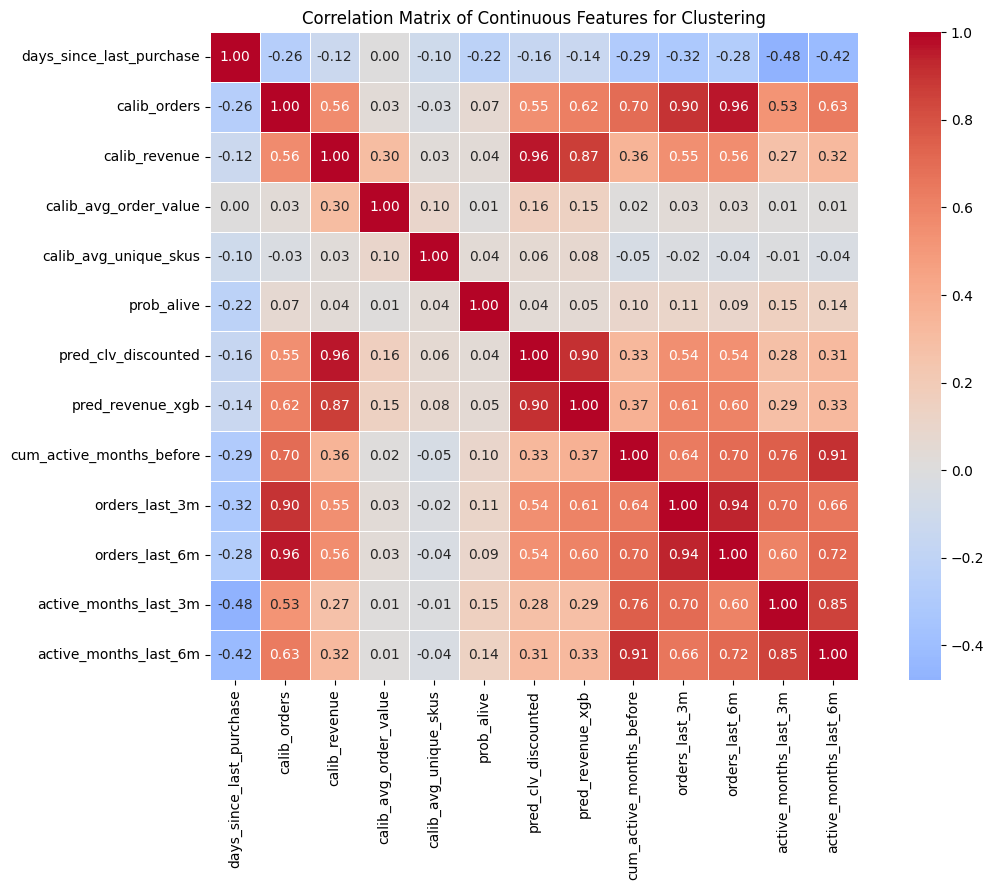

Highly correlated feature pairs (|corr| >= 0.7):


,feature_1,feature_2,correlation
2,calib_revenue,pred_clv_discounted,0.964049
1,calib_orders,orders_last_6m,0.960209
8,orders_last_3m,orders_last_6m,0.941029
7,cum_active_months_before,active_months_last_6m,0.911425
4,pred_clv_discounted,pred_revenue_xgb,0.904411
0,calib_orders,orders_last_3m,0.899496
3,calib_revenue,pred_revenue_xgb,0.869580
11,active_months_last_3m,active_months_last_6m,0.850174
6,cum_active_months_before,active_months_last_3m,0.755347
10,orders_last_6m,active_months_last_6m,0.715291


In [38]:
# ========== 32.5 Correlation check for clustering features ==========
import matplotlib.pyplot as plt
import seaborn as sns

# Use only continuous clustering features for correlation inspection
corr_features = [
    "days_since_last_purchase",
    "calib_orders",
    "calib_revenue",
    "calib_avg_order_value",
    "calib_avg_unique_skus",
    "prob_alive",
    "pred_clv_discounted",
    "pred_revenue_xgb",
    "cum_active_months_before",
    "orders_last_3m",
    "orders_last_6m",
    "active_months_last_3m",
    "active_months_last_6m"
]

corr_df = segment_df[corr_features].copy()

# Replace inf with NaN and impute missing values with median
corr_df = corr_df.replace([np.inf, -np.inf], np.nan)
for col in corr_df.columns:
    corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")
    corr_df[col] = corr_df[col].fillna(corr_df[col].median())

# Compute Pearson correlation matrix
corr_matrix = corr_df.corr(method="pearson")

# Display the matrix as a table
display(corr_matrix.round(2))

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix of Continuous Features for Clustering")
plt.tight_layout()
plt.show()

# Optional: display highly correlated feature pairs
high_corr_pairs = []
threshold = 0.70

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= threshold:
            high_corr_pairs.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "correlation",
    key=lambda x: x.abs(),
    ascending=False
)

print(f"Highly correlated feature pairs (|corr| >= {threshold}):")
display(high_corr_df)

In [39]:
# ========== 33. Clustering setup and K selection (Plan A: balanced feature set) ==========
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------
# Plan A: balanced clustering feature set
# One representative feature for each major dimension
# ------------------------------------------
cluster_features_plan_a = [
    "days_since_last_purchase",   # recency / risk
    "calib_orders",               # historical relationship depth
    "calib_avg_order_value",      # average order value
    "calib_avg_unique_skus",      # purchase breadth
    "prob_alive",                 # survival probability
    "pred_clv_discounted",        # long-term predicted value
    "active_months_last_3m"       # recent activity
]

cluster_df = segment_df[["CustomerID"] + cluster_features_plan_a].copy()

# ------------------------------------------
# Handle missing and infinite values
# ------------------------------------------
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)

for col in cluster_features_plan_a:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

# ------------------------------------------
# Log-transform CLV because it is usually skewed
# ------------------------------------------
cluster_df["log_pred_clv_discounted"] = np.log1p(cluster_df["pred_clv_discounted"].clip(lower=0))

# Final feature list for clustering
cluster_feature_cols = [
    "days_since_last_purchase",
    "calib_orders",
    "calib_avg_order_value",
    "calib_avg_unique_skus",
    "prob_alive",
    "log_pred_clv_discounted",
    "active_months_last_3m"
]

debug_matrix = cluster_df[cluster_feature_cols].astype(float)

print("Any NaN left in clustering matrix:", debug_matrix.isna().sum().sum())
print("Any inf left in clustering matrix:", np.isinf(debug_matrix.to_numpy()).sum())

# ------------------------------------------
# Standardize features
# ------------------------------------------
scaler = StandardScaler()
X_cluster = scaler.fit_transform(debug_matrix)

# ------------------------------------------
# Select K by silhouette score
# ------------------------------------------
k_candidates = range(3, 9)
k_selection = []

for k in k_candidates:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    k_selection.append({"k": k, "silhouette_score": score})

k_selection_df = pd.DataFrame(k_selection).sort_values("silhouette_score", ascending=False)
display(k_selection_df)

best_k = int(k_selection_df.iloc[0]["k"])
print("Selected number of clusters:", best_k)

Any NaN left in clustering matrix: 0
Any inf left in clustering matrix: 0


,k,silhouette_score
5,8,0.350634
3,6,0.338271
4,7,0.337855
2,5,0.322316
1,4,0.309790
0,3,0.308953


Selected number of clusters: 8


In [40]:
# ========== 34. Fit KMeans and profile clusters (Plan A) ==========
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
segment_df["cluster_segment"] = kmeans.fit_predict(X_cluster).astype(str)

cluster_summary = (
    segment_df.groupby("cluster_segment")
    .agg(
        customers=("CustomerID", "nunique"),
        avg_recency_days=("days_since_last_purchase", "mean"),
        avg_calib_orders=("calib_orders", "mean"),
        avg_aov=("calib_avg_order_value", "mean"),
        avg_unique_skus=("calib_avg_unique_skus", "mean"),
        avg_prob_alive=("prob_alive", "mean"),
        avg_clv=("pred_clv_discounted", "mean"),
        avg_recent_active_months=("active_months_last_3m", "mean"),
        avg_holdout_revenue=("actual_holdout_revenue", "mean"),
        avg_holdout_orders=("actual_holdout_orders", "mean")
    )
    .sort_values("avg_clv", ascending=False)
    .reset_index()
)

display(cluster_summary)

,cluster_segment,customers,avg_recency_days,avg_calib_orders,avg_aov,avg_unique_skus,avg_prob_alive,avg_clv,avg_recent_active_months,avg_holdout_revenue,avg_holdout_orders
0,5,22,5.500000,67.409091,1243.228920,17.381694,1.0,29587.316710,3.000000,7883.033636,9.909091
1,0,653,27.330781,10.013783,497.247334,19.731855,1.0,2368.952770,2.254211,695.458882,1.450230
2,7,362,60.176796,2.530387,741.826229,64.180173,1.0,1451.011688,0.604972,386.718425,0.558011
3,1,1872,44.084402,2.682692,329.847788,17.027327,1.0,622.298499,0.708868,133.367334,0.443910
4,4,38,282.157895,2.921053,289.726009,12.284701,1.0,327.166483,0.000000,82.218421,0.184211
5,6,242,166.144628,2.115702,305.943005,18.221074,1.0,310.801622,0.264463,59.004504,0.206612
6,3,877,235.364880,1.310148,296.044691,15.831243,1.0,200.729751,0.002281,49.423729,0.182440
7,2,1,295.000000,1.000000,77183.600000,1.000000,1.0,150.988439,0.000000,0.000000,0.000000


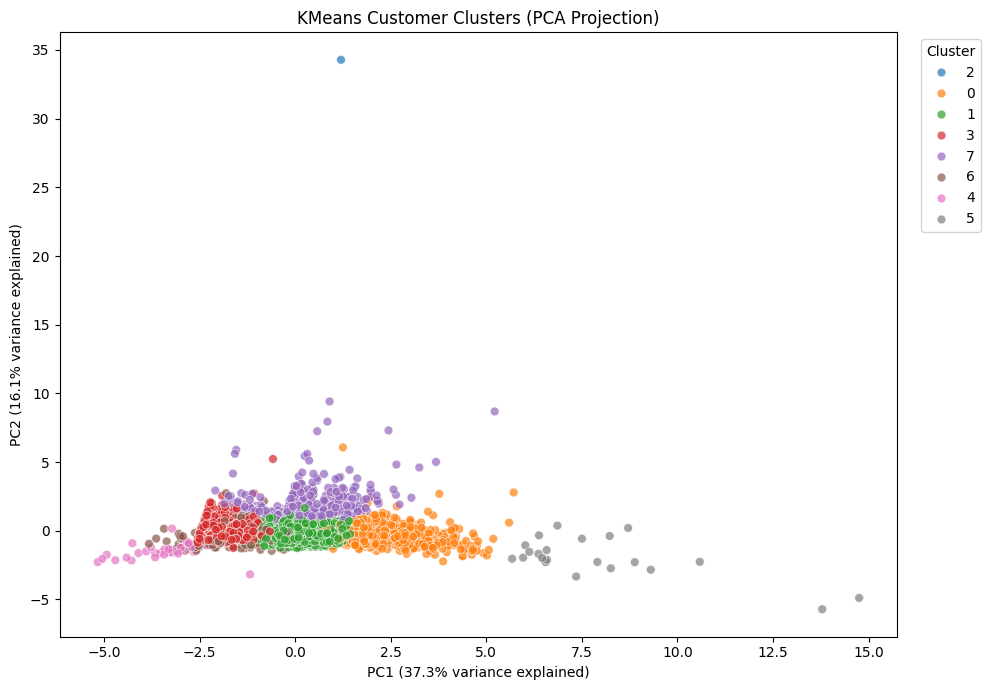

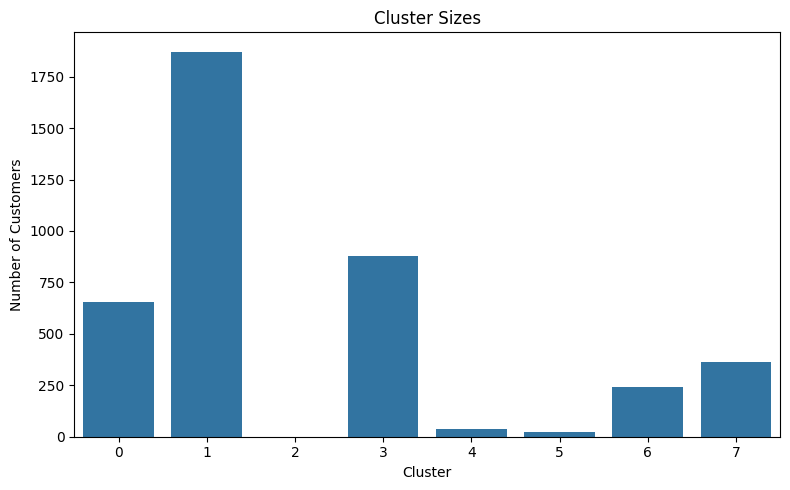

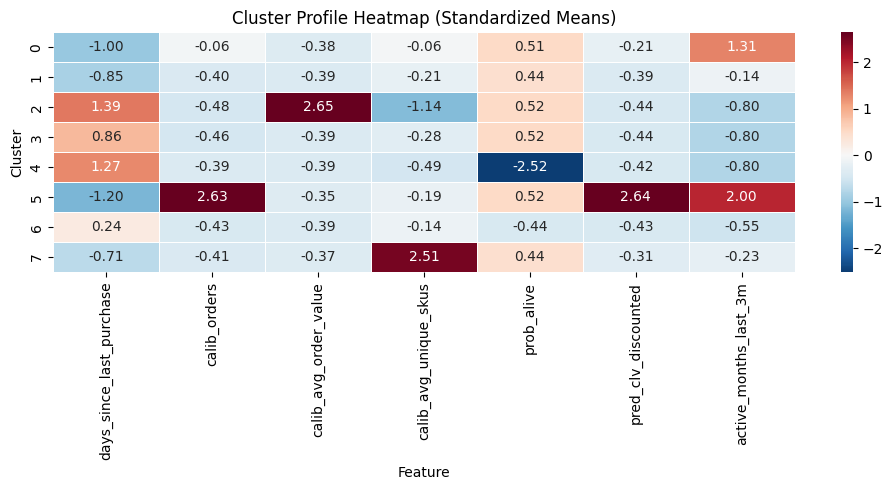

In [41]:
# ========== 34.5 Cluster visualization (Plan A) ==========
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ------------------------------------------
# 1. PCA 2D scatter plot
# ------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_cluster_2d = pca.fit_transform(X_cluster)

cluster_plot_df = pd.DataFrame({
    "PC1": X_cluster_2d[:, 0],
    "PC2": X_cluster_2d[:, 1],
    "cluster_segment": segment_df["cluster_segment"].astype(str).values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster_segment",
    palette="tab10",
    alpha=0.7,
    s=40
)
plt.title("KMeans Customer Clusters (PCA Projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance explained)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance explained)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------
# 2. Cluster size bar chart
# ------------------------------------------
cluster_size_df = (
    segment_df["cluster_segment"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cluster_size_df.columns = ["cluster_segment", "customers"]

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_size_df, x="cluster_segment", y="customers")
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# ------------------------------------------
# 3. Cluster profile heatmap
# ------------------------------------------
profile_cols = [
    "days_since_last_purchase",
    "calib_orders",
    "calib_avg_order_value",
    "calib_avg_unique_skus",
    "prob_alive",
    "pred_clv_discounted",
    "active_months_last_3m"
]

cluster_profile = (
    segment_df.groupby("cluster_segment")[profile_cols]
    .mean()
    .copy()
)

# Standardize by column for visualization only
cluster_profile_z = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std(ddof=0)

plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profile_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Cluster Profile Heatmap (Standardized Means)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [42]:
# ========== 35. Compare rule segmentation vs clustering ==========
def segmentation_separation_score(df, group_col, target_col):
    """
    Compute eta-squared style separation score:
    between-group sum of squares / total sum of squares.
    Higher means the segmentation explains more variance in the target.
    """
    tmp = df[[group_col, target_col]].dropna().copy()
    overall_mean = tmp[target_col].mean()

    group_stats = tmp.groupby(group_col)[target_col].agg(["count", "mean"]).reset_index()
    ss_between = ((group_stats["mean"] - overall_mean) ** 2 * group_stats["count"]).sum()
    ss_total = ((tmp[target_col] - overall_mean) ** 2).sum()

    eta_squared = ss_between / ss_total if ss_total > 0 else np.nan
    return eta_squared

comparison_targets = [
    "actual_holdout_revenue",
    "actual_holdout_orders",
    "pred_clv_discounted",
    "prob_alive"
]

comparison_rows = []

for target in comparison_targets:
    comparison_rows.append({
        "target": target,
        "rule_segment_eta2": segmentation_separation_score(segment_df, "rule_segment", target),
        "cluster_segment_eta2": segmentation_separation_score(segment_df, "cluster_segment", target)
    })

segmentation_comparison = pd.DataFrame(comparison_rows)
display(segmentation_comparison)

# Summaries for business interpretation
rule_eval = (
    segment_df.groupby("rule_segment")
    .agg(
        customers=("CustomerID", "nunique"),
        avg_holdout_revenue=("actual_holdout_revenue", "mean"),
        avg_holdout_orders=("actual_holdout_orders", "mean"),
        avg_prob_alive=("prob_alive", "mean"),
        avg_clv=("pred_clv_discounted", "mean")
    )
    .reset_index()
)

cluster_eval = (
    segment_df.groupby("cluster_segment")
    .agg(
        customers=("CustomerID", "nunique"),
        avg_holdout_revenue=("actual_holdout_revenue", "mean"),
        avg_holdout_orders=("actual_holdout_orders", "mean"),
        avg_prob_alive=("prob_alive", "mean"),
        avg_clv=("pred_clv_discounted", "mean")
    )
    .reset_index()
)

display(rule_eval)
display(cluster_eval)

,target,rule_segment_eta2,cluster_segment_eta2
0,actual_holdout_revenue,0.064185,0.249926
1,actual_holdout_orders,0.122474,0.314495
2,pred_clv_discounted,0.076807,0.396195
3,prob_alive,0.072347,0.811711


,rule_segment,customers,avg_holdout_revenue,avg_holdout_orders,avg_prob_alive,avg_clv
0,champions,670,927.729373,1.656716,1.0,3057.021260
1,dormant,1362,55.717100,0.197504,1.0,217.733603
2,growth_potential,175,70.798343,0.360000,1.0,317.378624
3,high_value_at_risk,917,281.409444,0.654308,1.0,1238.346198
4,loyal_mid_value,700,131.751186,0.404286,1.0,859.128133
5,mid_value,243,73.381646,0.370370,1.0,316.641224


,cluster_segment,customers,avg_holdout_revenue,avg_holdout_orders,avg_prob_alive,avg_clv
0,0,653,695.458882,1.450230,1.0,2368.952770
1,1,1872,133.367334,0.443910,1.0,622.298499
2,2,1,0.000000,0.000000,1.0,150.988439
3,3,877,49.423729,0.182440,1.0,200.729751
4,4,38,82.218421,0.184211,1.0,327.166483
5,5,22,7883.033636,9.909091,1.0,29587.316710
6,6,242,59.004504,0.206612,1.0,310.801622
7,7,362,386.718425,0.558011,1.0,1451.011688


In [43]:
# ========== 36. Choose primary segmentation ==========
# Use rule-based segmentation as the primary business-facing segmentation.
# Clustering is kept as a complementary validation view.
primary_segment_col = "rule_segment"

segment_df["primary_segment"] = segment_df[primary_segment_col]

segment_counts = (
    segment_df["primary_segment"]
    .value_counts(dropna=False)
    .rename_axis("primary_segment")
    .reset_index(name="customers")
)

display(segment_counts)

,primary_segment,customers
0,dormant,1362
1,high_value_at_risk,917
2,loyal_mid_value,700
3,champions,670
4,mid_value,243
5,growth_potential,175


## 8. Product Analysis: Association Rules + High-Value Customer Segmentation



In [44]:
# ========== 37. Product analysis setup using revenue Top N SKUs ==========
from mlxtend.frequent_patterns import apriori, association_rules

top_n_skus = 100   # adjust as needed
min_support = 0.01
min_confidence = 0.20
min_lift = 1.20

# Use clean line-level transaction data before calibration_end
product_tx = df[df["InvoiceDate"] <= calibration_end].copy()

# Keep only customers in the segmentation table
product_tx = product_tx[product_tx["CustomerID"].isin(segment_df["CustomerID"])].copy()

# Merge the primary business segmentation
product_tx = product_tx.merge(
    segment_df[["CustomerID", "primary_segment"]],
    on="CustomerID",
    how="left"
)

# Select revenue Top N SKUs
top_skus_by_revenue = (
    product_tx.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n_skus)
    .index
    .tolist()
)

product_tx_top = product_tx[product_tx["StockCode"].isin(top_skus_by_revenue)].copy()

print("Number of Top-N SKUs by revenue:", len(top_skus_by_revenue))
display(product_tx_top.head())

Number of Top-N SKUs by revenue: 100


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Date,YearMonth,Week,DayOfWeek,IsWeekend,Hour,Revenue,OrderDate,primary_segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,15.30,2010-12-01,high_value_at_risk
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,54.08,2010-12-01,champions
17,536367,21754,HOME BUILDING BLOCK WORD,3,2010-12-01 08:34:00,5.95,13047,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,17.85,2010-12-01,champions
20,536367,48187,DOORMAT NEW ENGLAND,4,2010-12-01 08:34:00,7.95,13047,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,31.80,2010-12-01,champions
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047,United Kingdom,False,2010-12-01,2010-12,48,2,0,8,25.50,2010-12-01,champions


In [45]:
# ========== 38. Top revenue products by segment ==========
top_revenue_products_by_segment = (
    product_tx_top.groupby(["primary_segment", "StockCode", "Description"], dropna=False)
    .agg(
        segment_revenue=("Revenue", "sum"),
        buyers=("CustomerID", "nunique"),
        orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values(["primary_segment", "segment_revenue"], ascending=[True, False])
)

top_revenue_products_by_segment = (
    top_revenue_products_by_segment.groupby("primary_segment", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_revenue_products_by_segment)

,primary_segment,StockCode,Description,segment_revenue,buyers,orders
0,champions,22423,REGENCY CAKESTAND 3 TIER,88720.83,239,695
1,champions,85099B,JUMBO BAG RED RETROSPOT,51782.99,209,778
2,champions,85123A,WHITE HANGING HEART T-LIGHT HOLDER,49096.18,236,801
3,champions,POST,POSTAGE,36772.72,76,442
4,champions,47566,PARTY BUNTING,31729.32,217,604
5,champions,M,Manual,25142.66,62,95
6,champions,22386,JUMBO BAG PINK POLKADOT,25034.89,145,473
7,champions,82484,WOOD BLACK BOARD ANT WHITE FINISH,23177.23,95,283
8,champions,23284,DOORMAT KEEP CALM AND COME IN,22447.17,134,278
9,champions,84879,ASSORTED COLOUR BIRD ORNAMENT,22264.48,188,506


In [46]:
# ========== 39. Top penetration products by segment ==========
segment_sizes = (
    product_tx_top.groupby("primary_segment")["CustomerID"]
    .nunique()
    .reset_index(name="segment_customers")
)

penetration_df = (
    product_tx_top.groupby(["primary_segment", "StockCode", "Description"])["CustomerID"]
    .nunique()
    .reset_index(name="buyers")
    .merge(segment_sizes, on="primary_segment", how="left")
)

penetration_df["penetration_rate"] = penetration_df["buyers"] / penetration_df["segment_customers"]

top_penetration_products_by_segment = (
    penetration_df.sort_values(["primary_segment", "penetration_rate"], ascending=[True, False])
    .groupby("primary_segment", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_penetration_products_by_segment)

,primary_segment,StockCode,Description,buyers,segment_customers,penetration_rate
0,champions,22423,REGENCY CAKESTAND 3 TIER,239,664,0.359940
1,champions,85123A,WHITE HANGING HEART T-LIGHT HOLDER,236,664,0.355422
2,champions,47566,PARTY BUNTING,217,664,0.326807
3,champions,21212,PACK OF 72 RETROSPOT CAKE CASES,213,664,0.320783
4,champions,85099B,JUMBO BAG RED RETROSPOT,209,664,0.314759
5,champions,22720,SET OF 3 CAKE TINS PANTRY DESIGN,205,664,0.308735
6,champions,20725,LUNCH BAG RED RETROSPOT,202,664,0.304217
7,champions,23298,SPOTTY BUNTING,202,664,0.304217
8,champions,84879,ASSORTED COLOUR BIRD ORNAMENT,188,664,0.283133
9,champions,23245,SET OF 3 REGENCY CAKE TINS,178,664,0.268072


In [47]:
# ========== 40. Association rules helper ==========
def build_association_rules(transactions, segment_name="all", min_support=0.01, min_confidence=0.20, min_lift=1.20):
    """
    Build association rules from invoice-level baskets.
    """
    if transactions.empty:
        return pd.DataFrame()

    basket = (
        transactions.groupby(["InvoiceNo", "StockCode"])["Quantity"]
        .sum()
        .unstack(fill_value=0)
    )

    basket = (basket > 0).astype(int)

    if basket.shape[0] < 50 or basket.shape[1] < 2:
        return pd.DataFrame()

    freq_itemsets = apriori(basket, min_support=min_support, use_colnames=True)

    if freq_itemsets.empty:
        return pd.DataFrame()

    rules = association_rules(freq_itemsets, metric="confidence", min_threshold=min_confidence)

    if rules.empty:
        return pd.DataFrame()

    rules = rules[rules["lift"] >= min_lift].copy()
    rules["segment"] = segment_name

    rules = rules.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False]
    )

    return rules

In [48]:
# ========== 41. Overall and segment-level association rules ==========
# Overall rules
overall_rules = build_association_rules(
    transactions=product_tx_top,
    segment_name="all",
    min_support=min_support,
    min_confidence=min_confidence,
    min_lift=min_lift
)

display(overall_rules.head(20))

# Segment-level rules for key business segments
focus_segments = ["champions", "high_value_at_risk", "growth_potential", "dormant"]

segment_rules_dict = {}

for seg in focus_segments:
    seg_tx = product_tx_top[product_tx_top["primary_segment"] == seg].copy()
    seg_rules = build_association_rules(
        transactions=seg_tx,
        segment_name=seg,
        min_support=min_support,
        min_confidence=min_confidence,
        min_lift=min_lift
    )
    segment_rules_dict[seg] = seg_rules

# Display top rules for each focus segment
for seg, rules_df in segment_rules_dict.items():
    print(f"\n===== Association Rules: {seg} =====")
    if rules_df.empty:
        print("No rules passed the thresholds.")
    else:
        display(rules_df.head(10))

D:\conda_envs\bigdata_group\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,segment
501,"(21929, 22386)",(21928),0.017763,0.036598,0.010642,0.599138,16.371005,1.0,0.009992,2.403327,0.955896,0.243433,0.583910,0.444966,all
502,(21928),"(21929, 22386)",0.036598,0.017763,0.010642,0.290795,16.371005,1.0,0.009992,1.384983,0.974584,0.243433,0.277970,0.444966,all
500,"(21928, 22386)",(21929),0.016078,0.041421,0.010642,0.661905,15.979923,1.0,0.009976,2.835234,0.952740,0.227124,0.647295,0.459418,all
503,(21929),"(21928, 22386)",0.041421,0.016078,0.010642,0.256932,15.979923,1.0,0.009976,1.324133,0.977928,0.227124,0.244789,0.459418,all
509,(21928),"(22411, 21929)",0.036598,0.017839,0.010413,0.284519,15.948929,1.0,0.009760,1.372727,0.972906,0.236522,0.271523,0.434105,all
504,"(22411, 21929)",(21928),0.017839,0.036598,0.010413,0.583691,15.948929,1.0,0.009760,2.314152,0.954324,0.236522,0.567876,0.434105,all
611,"(22423, 22699)",(22697),0.029094,0.047546,0.021668,0.744737,15.663459,1.0,0.020284,3.731263,0.964210,0.394150,0.731994,0.600227,all
612,(22697),"(22423, 22699)",0.047546,0.029094,0.021668,0.455717,15.663459,1.0,0.020284,1.783824,0.982890,0.394150,0.439407,0.600227,all
505,"(22411, 21928)",(21929),0.016078,0.041421,0.010413,0.647619,15.635032,1.0,0.009747,2.720292,0.951337,0.221138,0.632392,0.449503,all
508,(21929),"(22411, 21928)",0.041421,0.016078,0.010413,0.251386,15.635032,1.0,0.009747,1.314325,0.976488,0.221138,0.239153,0.449503,all


D:\conda_envs\bigdata_group\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
D:\conda_envs\bigdata_group\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
D:\conda_envs\bigdata_group\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
D:\conda_envs\bigdata_group\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-b


===== Association Rules: champions =====


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,segment
1178,"(20725, 23203)","(85099B, 23209)",0.021628,0.021628,0.011392,0.526718,24.353651,1.0,0.010924,2.067206,0.980137,0.357513,0.516255,0.526718,champions
1179,"(85099B, 23209)","(20725, 23203)",0.021628,0.021628,0.011392,0.526718,24.353651,1.0,0.010924,2.067206,0.980137,0.357513,0.516255,0.526718,champions
1158,"(20725, 22386)","(85099B, 22384)",0.023609,0.023774,0.012713,0.538462,22.649038,1.0,0.012151,2.115156,0.978960,0.366667,0.527222,0.536592,champions
1159,"(85099B, 22384)","(20725, 22386)",0.023774,0.023609,0.012713,0.534722,22.649038,1.0,0.012151,2.098512,0.979126,0.366667,0.523472,0.536592,champions
835,"(22328, POST)",(22326),0.012052,0.045732,0.010071,0.835616,18.271945,1.0,0.009520,5.805129,0.956803,0.211073,0.827739,0.527917,champions
839,(22326),"(22328, POST)",0.045732,0.012052,0.010071,0.220217,18.271945,1.0,0.009520,1.266952,0.990572,0.211073,0.210704,0.527917,champions
1208,"(21928, 22386)","(21929, 85099B)",0.022784,0.029883,0.011722,0.514493,17.217031,1.0,0.011041,1.998152,0.963879,0.286290,0.499538,0.453379,champions
1209,"(21929, 85099B)","(21928, 22386)",0.029883,0.022784,0.011722,0.392265,17.217031,1.0,0.011041,1.607965,0.970932,0.286290,0.378096,0.453379,champions
1211,"(21929, 22386)","(85099B, 21928)",0.024269,0.029222,0.011722,0.482993,16.528191,1.0,0.011013,1.877688,0.962866,0.280632,0.467430,0.442062,champions
1206,"(85099B, 21928)","(21929, 22386)",0.029222,0.024269,0.011722,0.401130,16.528191,1.0,0.011013,1.629286,0.967778,0.280632,0.386234,0.442062,champions


...

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,segment
1236,"(85099B, 23209)","(20725, 23203)",0.020828,0.019717,0.010830,0.520000,26.373521,1.0,0.010420,2.042257,0.982547,0.364486,0.510346,0.534648,high_value_at_risk
1235,"(20725, 23203)","(85099B, 23209)",0.019717,0.020828,0.010830,0.549296,26.373521,1.0,0.010420,2.172539,0.981434,0.364486,0.539709,0.534648,high_value_at_risk
1280,"(21929, 85099B)","(21928, 22386)",0.024993,0.015829,0.010275,0.411111,25.972125,1.0,0.009879,1.671234,0.986144,0.336364,0.401640,0.530117,high_value_at_risk
1279,"(21928, 22386)","(21929, 85099B)",0.015829,0.024993,0.010275,0.649123,25.972125,1.0,0.009879,2.778770,0.976961,0.336364,0.640129,0.530117,high_value_at_risk
1289,"(22411, 21928)","(85099B, 21929)",0.019439,0.024993,0.010830,0.557143,22.291905,1.0,0.010344,2.201629,0.974076,0.322314,0.545791,0.495238,high_value_at_risk
1294,"(85099B, 21929)","(22411, 21928)",0.024993,0.019439,0.010830,0.433333,22.291905,1.0,0.010344,1.730402,0.979624,0.322314,0.422099,0.495238,high_value_at_risk
1216,"(85099B, 22383)","(21931, 20725)",0.024438,0.019994,0.010830,0.443182,22.165246,1.0,0.010342,1.760010,0.978804,0.322314,0.431821,0.492424,high_value_at_risk
1215,"(21931, 20725)","(85099B, 22383)",0.019994,0.024438,0.010830,0.541667,22.165246,1.0,0.010342,2.128500,0.974366,0.322314,0.530186,0.492424,high_value_at_risk
1312,"(22411, 22386)","(85099B, 21929)",0.021105,0.024993,0.011663,0.552632,22.111404,1.0,0.011136,2.179427,0.975360,0.338710,0.541164,0.509649,high_value_at_risk
1317,"(85099B, 21929)","(22411, 22386)",0.024993,0.021105,0.011663,0.466667,22.111404,1.0,0.011136,1.835428,0.979249,0.338710,0.455168,0.509649,high_value_at_risk



===== Association Rules: growth_potential =====


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,segment
283,"(20725, 22383)","(20727, 22384)",0.010554,0.018470,0.010554,1.000000,54.142857,1.0,0.010359,inf,0.992000,0.571429,1.000000,0.785714,growth_potential
288,"(20727, 22384)","(20725, 22383)",0.018470,0.010554,0.010554,0.571429,54.142857,1.0,0.010359,2.308707,1.000000,0.571429,0.566857,0.785714,growth_potential
270,"(20725, 20728)","(20727, 22384)",0.015831,0.018470,0.013193,0.833333,45.119048,1.0,0.012900,5.889182,0.993566,0.625000,0.830197,0.773810,growth_potential
273,"(20727, 22384)","(20725, 20728)",0.018470,0.015831,0.013193,0.714286,45.119048,1.0,0.012900,3.444591,0.996237,0.625000,0.709690,0.773810,growth_potential
272,"(20727, 20728)","(20725, 22384)",0.015831,0.023747,0.013193,0.833333,35.092593,1.0,0.012817,5.857520,0.987131,0.500000,0.829279,0.694444,growth_potential
271,"(20725, 22384)","(20727, 20728)",0.023747,0.015831,0.013193,0.555556,35.092593,1.0,0.012817,2.214380,0.995135,0.500000,0.548406,0.694444,growth_potential
287,"(22384, 22383)","(20725, 20727)",0.013193,0.023747,0.010554,0.800000,33.688889,1.0,0.010241,4.881266,0.983289,0.400000,0.795135,0.622222,growth_potential
284,"(20725, 20727)","(22384, 22383)",0.023747,0.013193,0.010554,0.444444,33.688889,1.0,0.010241,1.776253,0.993919,0.400000,0.437017,0.622222,growth_potential
178,"(20727, 22384)",(20725),0.018470,0.031662,0.018470,1.000000,31.583333,1.0,0.017885,inf,0.986559,0.583333,1.000000,0.791667,growth_potential
268,"(20727, 20728, 22384)",(20725),0.013193,0.031662,0.013193,1.000000,31.583333,1.0,0.012775,inf,0.981283,0.416667,1.000000,0.708333,growth_potential



===== Association Rules: dormant =====


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,segment
61,(22629),(22630),0.026735,0.026735,0.017187,0.642857,24.045918,1.0,0.016472,2.725143,0.984739,0.473684,0.633047,0.642857,dormant
62,(22630),(22629),0.026735,0.026735,0.017187,0.642857,24.045918,1.0,0.016472,2.725143,0.984739,0.473684,0.633047,0.642857,dormant
35,(22086),(22910),0.025461,0.021642,0.012094,0.475000,21.947794,1.0,0.011543,1.863539,0.979374,0.345455,0.463386,0.516912,dormant
34,(22910),(22086),0.021642,0.025461,0.012094,0.558824,21.947794,1.0,0.011543,2.208954,0.975550,0.345455,0.547297,0.516912,dormant
78,(22727),(22726),0.032463,0.019096,0.013367,0.411765,21.562745,1.0,0.012747,1.667537,0.985620,0.350000,0.400313,0.555882,dormant
77,(22726),(22727),0.019096,0.032463,0.013367,0.700000,21.562745,1.0,0.012747,3.225122,0.972189,0.350000,0.689934,0.555882,dormant
30,(21928),(21929),0.022915,0.027371,0.012731,0.555556,20.297158,1.0,0.012104,2.188415,0.973029,0.338983,0.543048,0.510336,dormant
29,(21929),(21928),0.027371,0.022915,0.012731,0.465116,20.297158,1.0,0.012104,1.826723,0.977487,0.338983,0.452572,0.510336,dormant
37,(22112),(22111),0.020369,0.027371,0.010821,0.531250,19.409157,1.0,0.010264,2.074942,0.968199,0.293103,0.518059,0.463299,dormant
36,(22111),(22112),0.027371,0.020369,0.010821,0.395349,19.409157,1.0,0.010264,1.620159,0.975169,0.293103,0.382776,0.463299,dormant


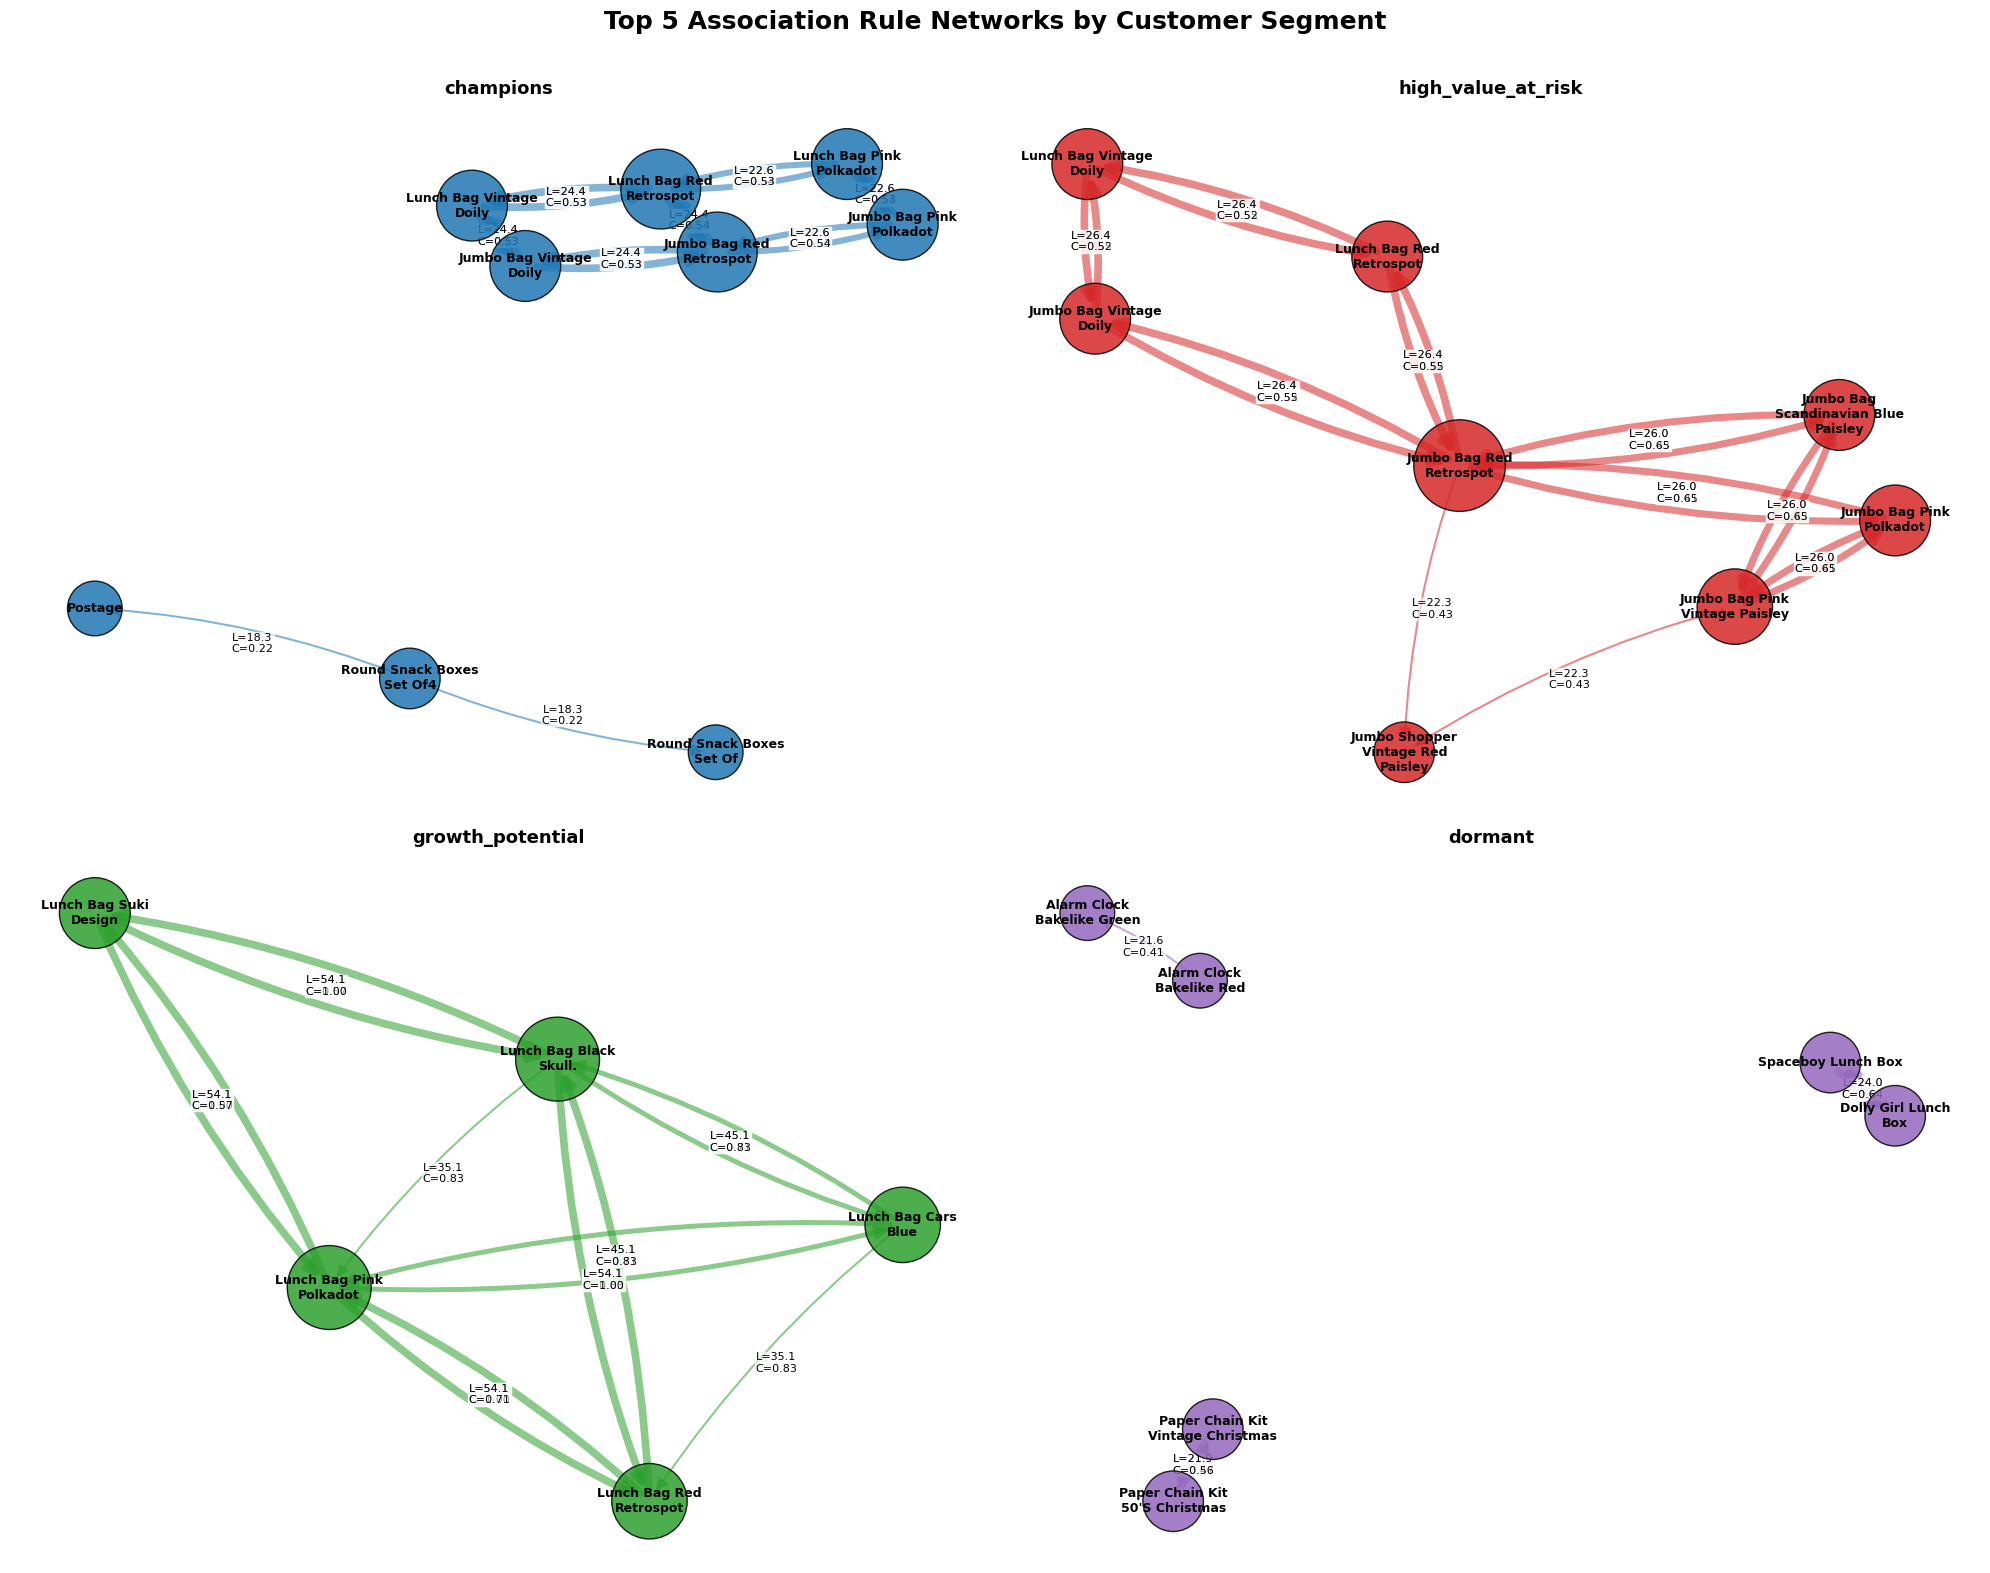

In [49]:
# ========== 41.5 Segment-level association rule network visualization ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import textwrap

# --------------------------------------------------
# Step 1: Build StockCode -> Product Description mapping
# Replace "df" with your cleaned line-item transaction dataframe if needed
# --------------------------------------------------
line_item_df = df.copy()

product_name_map_df = (
    line_item_df[["StockCode", "Description"]]
    .dropna()
    .assign(
        StockCode=lambda x: x["StockCode"].astype(str).str.strip(),
        Description=lambda x: x["Description"].astype(str).str.strip()
    )
)

# Use the most frequent description for each StockCode
product_name_map = (
    product_name_map_df
    .groupby(["StockCode", "Description"])
    .size()
    .reset_index(name="freq")
    .sort_values(["StockCode", "freq"], ascending=[True, False])
    .drop_duplicates(subset=["StockCode"])
    .set_index("StockCode")["Description"]
    .to_dict()
)

# --------------------------------------------------
# Step 2: Helper functions
# --------------------------------------------------
def clean_product_label(stock_code, name_map, max_words=5, wrap_width=18):
    """
    Convert StockCode to a readable product name.
    Fallback to StockCode if description is unavailable.
    """
    stock_code = str(stock_code)
    name = name_map.get(stock_code, stock_code)
    name = " ".join(str(name).split()[:max_words])
    name = name.title()
    name = textwrap.fill(name, width=wrap_width)
    return name

def get_top_rules(rules_df, top_n=5, metric="lift"):
    """
    Select top N rules sorted by a chosen metric.
    """
    if rules_df is None or rules_df.empty:
        return pd.DataFrame()
    return rules_df.sort_values(metric, ascending=False).head(top_n).copy()

def build_rule_network(rules_df, product_name_map):
    """
    Build a directed graph from association rules.
    Each antecedent item connects to each consequent item.
    Edge attributes store lift, confidence, and support.
    """
    G = nx.DiGraph()

    if rules_df is None or rules_df.empty:
        return G

    for _, row in rules_df.iterrows():
        antecedents = [str(x) for x in row["antecedents"]]
        consequents = [str(x) for x in row["consequents"]]

        antecedent_labels = [clean_product_label(x, product_name_map) for x in antecedents]
        consequent_labels = [clean_product_label(x, product_name_map) for x in consequents]

        for a in antecedent_labels:
            for c in consequent_labels:
                if G.has_edge(a, c):
                    # Keep the strongest metrics if the edge appears again
                    G[a][c]["lift"] = max(G[a][c]["lift"], row["lift"])
                    G[a][c]["confidence"] = max(G[a][c]["confidence"], row["confidence"])
                    G[a][c]["support"] = max(G[a][c]["support"], row["support"])
                    G[a][c]["count"] += 1
                else:
                    G.add_edge(
                        a,
                        c,
                        lift=row["lift"],
                        confidence=row["confidence"],
                        support=row["support"],
                        count=1
                    )

    return G

def plot_rule_network(ax, G, segment_name, color):
    """
    Plot one segment's association-rule network.
    """
    ax.set_title(f"{segment_name}", fontsize=13, fontweight="bold")

    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "No rules passed thresholds", ha="center", va="center", fontsize=12)
        ax.axis("off")
        return

    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.2 / np.sqrt(max(G.number_of_nodes(), 1)))

    # Node sizes based on degree
    node_sizes = [1200 + 350 * G.degree(n) for n in G.nodes()]

    # Edge widths based on lift
    edge_lifts = np.array([d["lift"] for _, _, d in G.edges(data=True)])
    if len(edge_lifts) > 0:
        if edge_lifts.max() == edge_lifts.min():
            edge_widths = [2.5] * len(edge_lifts)
        else:
            edge_widths = 1.5 + 4 * (edge_lifts - edge_lifts.min()) / (edge_lifts.max() - edge_lifts.min())
    else:
        edge_widths = [2.0]

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=color,
        alpha=0.85,
        edgecolors="black",
        linewidths=1
    )

    # Draw edges
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_widths,
        edge_color=color,
        alpha=0.55,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.08"
    )

    # Draw labels
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=9,
        font_weight="bold"
    )

    # Edge labels: show lift and confidence
    edge_labels = {
        (u, v): f"L={d['lift']:.1f}\nC={d['confidence']:.2f}"
        for u, v, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        ax=ax,
        edge_labels=edge_labels,
        font_size=8,
        rotate=False,
        bbox=dict(alpha=0.6, color="white", edgecolor="none", pad=0.2)
    )

    ax.axis("off")

# --------------------------------------------------
# Step 3: Choose business segments and colors
# --------------------------------------------------
focus_segments = ["champions", "high_value_at_risk", "growth_potential", "dormant"]

segment_colors = {
    "champions": "#1f77b4",          # blue
    "high_value_at_risk": "#d62728", # red
    "growth_potential": "#2ca02c",   # green
    "dormant": "#9467bd"             # purple
}

# --------------------------------------------------
# Step 4: Plot top-5 rule networks for each segment
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for ax, seg in zip(axes, focus_segments):
    rules_df = segment_rules_dict.get(seg, pd.DataFrame())
    top_rules_df = get_top_rules(rules_df, top_n=5, metric="lift")
    G = build_rule_network(top_rules_df, product_name_map)
    plot_rule_network(ax, G, seg, segment_colors.get(seg, "#7f7f7f"))

plt.suptitle("Top 5 Association Rule Networks by Customer Segment", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Association rules.png") 
plt.show()

In [50]:
# ========== 42. Product analysis summary tables ==========
# Segment-level revenue share
segment_revenue_summary = (
    product_tx.groupby("primary_segment")["Revenue"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
)

# Segment-level order count
segment_order_summary = (
    product_tx.groupby("primary_segment")["InvoiceNo"]
    .nunique()
    .reset_index(name="n_orders")
    .sort_values("n_orders", ascending=False)
)

display(segment_revenue_summary)
display(segment_order_summary)

,primary_segment,total_revenue
0,champions,4245836.080
3,high_value_at_risk,1978239.512
1,dormant,632378.160
4,loyal_mid_value,487518.271
5,mid_value,104616.170
2,growth_potential,77464.101


,primary_segment,n_orders
0,champions,7220
3,high_value_at_risk,4199
1,dormant,2027
4,loyal_mid_value,1276
2,growth_potential,512
5,mid_value,499


In [51]:
# ========== 34. 客户订单状态路径 ==========
order_path = order_level.copy()
order_path["order_seq"] = order_path.sort_values("InvoiceDate").groupby("CustomerID").cumcount() + 1

# 基于订单特征定义状态
aov_median = order_path["order_revenue"].median()
sku_median = order_path["unique_skus"].median()

def order_state(row):
    if row["order_revenue"] >= aov_median and row["unique_skus"] > sku_median:
        return "high_value_multi_sku"
    elif row["order_revenue"] >= aov_median:
        return "high_value_single_focus"
    elif row["unique_skus"] > sku_median:
        return "low_value_multi_sku"
    else:
        return "low_value_single_sku"

order_path["order_state"] = order_path.apply(order_state, axis=1)

# 每个客户取前3单路径
first3 = order_path[order_path["order_seq"] <= 3].copy()
path_table = (
    first3.sort_values(["CustomerID", "order_seq"])
          .groupby("CustomerID")["order_state"]
          .apply(lambda x: " -> ".join(x.tolist()))
          .reset_index(name="path_first3")
)

display(path_table["path_first3"].value_counts().head(20))


path_first3
low_value_single_sku                                                             568
high_value_multi_sku                                                             485
high_value_multi_sku -> high_value_multi_sku -> high_value_multi_sku             279
low_value_multi_sku                                                              272
low_value_single_sku -> low_value_single_sku -> low_value_single_sku             239
low_value_single_sku -> low_value_single_sku                                     206
high_value_single_focus                                                          168
high_value_multi_sku -> high_value_multi_sku                                     155
low_value_multi_sku -> low_value_multi_sku -> low_value_multi_sku                106
high_value_multi_sku -> high_value_multi_sku -> low_value_single_sku              97
high_value_multi_sku -> low_value_single_sku -> low_value_single_sku              87
high_value_multi_sku -> low_value_single_sku         

In [52]:
# ========== 35. 商品演化路径 ==========
# 看首单商品 -> 第二单新增商品
order_seq_skus = (
    df.merge(order_path[["InvoiceNo", "CustomerID", "order_seq"]], on=["InvoiceNo", "CustomerID"], how="left")
      .groupby(["CustomerID", "order_seq"])["StockCode"]
      .apply(lambda x: set(x))
      .reset_index(name="sku_set")
)

seq1 = order_seq_skus[order_seq_skus["order_seq"] == 1][["CustomerID", "sku_set"]].rename(columns={"sku_set": "sku_set_1"})
seq2 = order_seq_skus[order_seq_skus["order_seq"] == 2][["CustomerID", "sku_set"]].rename(columns={"sku_set": "sku_set_2"})

path_sku = seq1.merge(seq2, on="CustomerID", how="inner")
path_sku["new_skus_in_order2"] = path_sku.apply(lambda r: len(r["sku_set_2"] - r["sku_set_1"]), axis=1)
path_sku["repeat_skus_in_order2"] = path_sku.apply(lambda r: len(r["sku_set_2"].intersection(r["sku_set_1"])), axis=1)

display(path_sku.head())
print("Order2 average new SKU count:", path_sku["new_skus_in_order2"].mean())
print("Order2 average repeated SKU count:", path_sku["repeat_skus_in_order2"].mean())


,CustomerID,sku_set_1,sku_set_2,new_skus_in_order2,repeat_skus_in_order2
0,12347,"{85232D, 84997D, 22492, 85167B, 84997C, 21731,...","{21832, 22417, 47559B, 84625C, 22134, 21731, 2...",18,11
1,12348,"{84992, 21211, 21981, 21977, 22951, 21982, 226...","{21980, 21983, 21726, 21985, POST, 21967}",5,1
2,12352,"{22646, 21755, 22780, 21700, 21756, 22853, 224...","{22138, 84050, POST, 22844, 22654}",4,1
3,12356,"{84987, 37501, 22435, 84569D, 21231, 22131, 22...","{21122, 21086, 22938, 21125, 21124, 20971, 228...",17,4
4,12358,"{15056P, 22063, 15060B, 48185, 37449, 15056BL,...","{15056P, 22646, 15056BL, 15056N, POST, 22059, ...",1,6


Order2 average new SKU count: 16.629525483304043
Order2 average repeated SKU count: 3.591212653778559
